# Comprehensive Results Analysis
## Bike Demand Forecasting Study — Multi-City (v5+)

Structure:
- **Section 0**: Config & helpers
- **Section 1**: Load data
- **Section 2**: Per-city analysis (loop over Seoul / London / Washington)
  - RQ1.1 Model rankings
  - RQ1.2 Weather covariate impact (TabPFN)
  - RQ1.3 Weather degradation impact
  - Variance / stability
- **Section 3**: Cross-city comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

## Section 0: Config & Helpers

In [2]:
# ── Experiment config ────────────────────────────────────────────────────────
RESULTS_VERSION = "v6"          # primary filter; used everywhere
DATASETS        = ["seoul", "london", "washington"]


MODEL_ORDER = [
    "TabPFN",
    "XGBoost",
    "TabPFN_NoWeather",
    "TimesFM_NoWeather",
    # "TabPFN_NoWeather_v3",
    # "TabPFN_v3",
    "Seasonal_Naive",
    "Prophet",
    "SARIMAX",
    "NeuralProphet_NoWeather",
    "NeuralProphet",
    "ARIMA",
    # "Prophet_Untuned",
    # "NeuralProphet_Untuned",
    # "NeuralProphet_NoWeather_Untuned",

]


# Models that use weather covariates and therefore appear in the degraded scenario.
# NeuralProphet_NoWeather, TabPFN_NoWeather, Seasonal_Naive, ARIMA, and Prophet
# do NOT use covariates and are intentionally excluded.
WEATHER_MODELS = ["XGBoost", "SARIMAX", "TabPFN", 
                  # "TabPFN_v3", 
                  "NeuralProphet",
                #   "NeuralProphet_Untuned",
                  ]

# define all models from MODEL_ORDER that are NOT in WEATHER_MODELS
NOWEATHER_MODELS_LIST = [model for model in MODEL_ORDER if model not in WEATHER_MODELS]


In [3]:
# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':      300,
    'savefig.dpi':     300,
    'font.size':       10,
    'axes.labelsize':  10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'lines.markersize': 8,
})

colors = sns.color_palette('Set2', 8)

In [4]:
def filter_results(df, version, dataset):
    """
    Filter to a single (version, dataset) slice and deduplicate.

    Parameters
    ----------
    df      : raw results DataFrame (agg or detailed)
    version : e.g. 'v5' — matches the `version` column
    dataset : e.g. 'seoul'

    Returns
    -------
    Filtered DataFrame with one row per unique
    (dataset, [fold], model, horizon, weather_scenario) combination,
    keeping the latest timestamp in case of reruns.
    """
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # ── Level 1: version filter ──────────────────────────────────────────────
    if version not in df["version"].values:
        available = df["version"].unique().tolist()
        raise ValueError(f"version '{version}' not found. Available: {available}")
    df = df[df["version"] == version].copy()

    # ── Level 2: dataset filter ──────────────────────────────────────────────
    if dataset not in df["dataset"].values:
        available = df["dataset"].unique().tolist()
        raise ValueError(f"dataset '{dataset}' not found in version '{version}'. Available: {available}")
    df = df[df["dataset"] == dataset].copy()

    # ── Deduplication grouping keys ──────────────────────────────────────────
    has_fold            = "fold" in df.columns
    has_weather_scenario = "weather_scenario" in df.columns

    group_cols = ["dataset"]
    if has_fold:
        group_cols += ["fold"]
    group_cols += ["model", "horizon"]
    if has_weather_scenario:
        group_cols += ["weather_scenario"]

    # Guard: identical timestamps within same group indicate a logic error
    dupes = df.duplicated(subset=group_cols + ["timestamp"], keep=False)
    if dupes.any():
        raise ValueError(
            f"Identical timestamps found for the same group. "
            f"Indices: {df[dupes].index.tolist()}"
        )

    # Keep latest timestamp per combination (handles partial reruns)
    df = (
        df.sort_values("timestamp")
          .drop_duplicates(subset=group_cols, keep="last")
          .reset_index(drop=True)
    )
    return df

## Section 1: Load Data

In [5]:
df_agg      = pd.read_csv(f'../results/results_master_{RESULTS_VERSION}.csv')
df_detailed = pd.read_csv(f'../results/detailed_results_master_{RESULTS_VERSION}.csv')


In [6]:
# remove models from analysis:
# df_agg only models in MODEL_ORDER 
df_agg = df_agg[df_agg["model"].isin(MODEL_ORDER)]

# df_detailed only models in MODEL_ORDER
df_detailed = df_detailed[df_detailed["model"].isin(MODEL_ORDER)]


In [7]:

print(f"Aggregated  : {df_agg.shape}")
print(f"Detailed    : {df_detailed.shape}")
print(f"Datasets    : {sorted(df_agg['dataset'].unique())}")
print(f"Versions    : {sorted(df_agg['version'].unique())}")
print(f"Models      : {sorted(df_agg['model'].unique())}")
print(f"Horizons    : {sorted(df_agg['horizon'].unique())}")
print(f"Scenarios   : {sorted(df_agg['weather_scenario'].unique())}")

Aggregated  : (168, 22)
Detailed    : (58044, 17)
Datasets    : ['london', 'seoul', 'washington']
Versions    : ['v6']
Models      : ['ARIMA', 'NeuralProphet', 'NeuralProphet_NoWeather', 'Prophet', 'SARIMAX', 'Seasonal_Naive', 'TabPFN', 'TabPFN_NoWeather', 'TimesFM_NoWeather', 'XGBoost']
Horizons    : [6, 24, 48, 168]
Scenarios   : ['clean_only', 'degraded']


In [8]:
# Create output directories
for ds in DATASETS:
    Path(f'../results/figures/{ds}').mkdir(parents=True, exist_ok=True)
    Path(f'../results/tables/{ds}').mkdir(parents=True, exist_ok=True)

Path('../results/figures/cross_city').mkdir(parents=True, exist_ok=True)
Path('../results/tables/cross_city').mkdir(parents=True, exist_ok=True)

print("Output directories ready.")

Output directories ready.


In [9]:
# ── Cross-city overall ranking ────────────────────────────────────────────────
# Computed once here so MODEL_ORDER_RANKED can be used consistently in every
# figure and table throughout the notebook (both per-city and cross-city).
#
# Metric: MASE averaged across all cities and all horizons (clean_only only).
# MASE is city-agnostic by construction, making it the right choice for
# cross-city aggregation. MODEL_ORDER is used as a tiebreaker for equal values.

frames_clean_all = []
for ds in DATASETS:
    df_c = filter_results(df_agg, RESULTS_VERSION, ds)
    frames_clean_all.append(df_c[df_c['weather_scenario'] == 'clean_only'])

df_clean_all = pd.concat(frames_clean_all, ignore_index=True)

cross_city_ranking = (
    df_clean_all.groupby('model')
    .agg(
        MASE  =('MASE_mean',  'mean'),
        MAE   =('MAE_mean',   'mean'),
        RMSE  =('RMSE_mean',  'mean'),
        sMAPE =('sMAPE_mean', 'mean'),
    )
    .round(3)
)

# Tiebreak by MODEL_ORDER position for models with identical MASE
cross_city_ranking['_order'] = cross_city_ranking.index.map(
    lambda m: MODEL_ORDER.index(m) if m in MODEL_ORDER else len(MODEL_ORDER)
)
cross_city_ranking = cross_city_ranking.sort_values(['MASE', '_order']).drop(columns='_order')
cross_city_ranking.insert(0, 'Rank', range(1, len(cross_city_ranking) + 1))

best = cross_city_ranking.iloc[0]
for metric in ['MASE', 'MAE', 'RMSE', 'sMAPE']:
    cross_city_ranking[f'delta_{metric}'] = (cross_city_ranking[metric] - best[metric]).round(3)
    cross_city_ranking.loc[cross_city_ranking.index[0], f'delta_{metric}'] = np.nan

# The ranked model list — used everywhere below instead of the hardcoded MODEL_ORDER
MODEL_ORDER_RANKED = cross_city_ranking.index.tolist()

print("Cross-city ranking (MASE, averaged over all cities and horizons):")
print(cross_city_ranking[['Rank','MASE','MAE','RMSE','sMAPE']].to_string())
print(f"\nMODEL_ORDER_RANKED: {MODEL_ORDER_RANKED}")

# ── Save table ────────────────────────────────────────────────────────────────
cross_city_ranking.to_csv('../results/tables/cross_city/tableC0_overall_ranking.csv')

tex  = "\\begin{table}[ht!]\n\\centering\n"
tex += "\\caption{Overall cross-city model ranking by mean MASE (clean weather, "
tex += "averaged over all cities and forecast horizons). "
tex += "Delta columns show differences relative to the best-ranked model.}\n"
tex += "\\label{tab:cross_city_overall_ranking}\n"
tex += "{\\small\\setlength{\\tabcolsep}{3pt}\\scriptsize\n"
tex += "\\begin{tabular}{clrlrlrlrl}\n\\toprule\n"
tex += "Rank & Model & MASE & ~~\\(\\Delta\\) & MAE & ~~\\(\\Delta\\) & RMSE & ~~\\(\\Delta\\) & sMAPE & ~~\\(\\Delta\\) \\\\\n"
tex += "\\midrule\n"
for model, row in cross_city_ranking.iterrows():
    def d(col):
        v = row[f'delta_{col}']
        return '' if pd.isna(v) else f'+{v:.3f}'
    tex += (f"{int(row['Rank'])} & {model} "
            f"& {row['MASE']:.3f} & {d('MASE')} "
            f"& {row['MAE']:.1f} & {d('MAE')} "
            f"& {row['RMSE']:.1f} & {d('RMSE')} "
            f"& {row['sMAPE']:.2f} & {d('sMAPE')} \\\\\n")
tex += "\\bottomrule\n\\end{tabular}\n}\n\\end{table}\n"
with open('../results/tables/cross_city/tableC0_overall_ranking.tex', 'w') as f:
    f.write(tex)
print("\\nTableC0 saved.")

Cross-city ranking (MASE, averaged over all cities and horizons):
                         Rank   MASE      MAE     RMSE   sMAPE
model                                                         
TabPFN                      1  0.622  153.065  225.937  25.944
TimesFM_NoWeather           2  0.630  159.789  226.139  28.421
XGBoost                     3  0.717  176.630  253.793  28.776
TabPFN_NoWeather            4  0.771  195.496  281.265  29.851
Seasonal_Naive              5  1.106  276.778  401.740  42.754
Prophet                     6  1.295  330.998  429.823  57.689
SARIMAX                     7  1.431  384.194  483.125  60.016
NeuralProphet_NoWeather     8  1.871  475.381  616.990  72.379
NeuralProphet               9  1.880  471.671  610.465  73.482
ARIMA                      10  2.114  563.662  719.884  77.566

MODEL_ORDER_RANKED: ['TabPFN', 'TimesFM_NoWeather', 'XGBoost', 'TabPFN_NoWeather', 'Seasonal_Naive', 'Prophet', 'SARIMAX', 'NeuralProphet_NoWeather', 'NeuralProphet', 'ARIMA']
\

## Section 2: Per-City Analysis

Sections 2.1–2.4 run identically for each city. All outputs are written to
`results/figures/{dataset}/` and `results/tables/{dataset}/`.

In [31]:
for dataset in DATASETS:
    print(f"\n{'='*60}")
    print(f"  Processing: {dataset.upper()}")
    print(f"{'='*60}")

    FIG  = lambda name: f'../results/figures/{dataset}/{dataset}_{name}'
    TAB  = lambda name: f'../results/tables/{dataset}/{dataset}_{name}'

    # ── Load & split ──────────────────────────────────────────────────────────
    df_city     = filter_results(df_agg,      RESULTS_VERSION, dataset)
    df_det_city = filter_results(df_detailed, RESULTS_VERSION, dataset)

    df_clean    = df_city[df_city['weather_scenario'] == 'clean_only'].copy()
    df_degraded = df_city[df_city['weather_scenario'] == 'degraded'].copy()

    df_det_clean    = df_det_city[df_det_city['weather_scenario'] == 'clean_only'].copy()
    df_det_degraded = df_det_city[df_det_city['weather_scenario'] == 'degraded'].copy()

    horizons = sorted(df_clean['horizon'].astype(int).unique())
    horizon_labels = [f"{h}h" for h in horizons]

    available_models = [m for m in MODEL_ORDER_RANKED if m in df_clean['model'].unique()]
    weather_models   = [m for m in WEATHER_MODELS if m in df_clean['model'].unique()
                        and m in df_degraded['model'].unique()]

    print(f"  Models     : {available_models}")
    print(f"  Horizons   : {horizons}")
    print(f"  Folds      : {sorted(df_det_city['fold'].unique())}")


    # ────────────────────────────────────────────────────────────────────────
    # 2.1  RQ1.1 — Model Rankings
    # ────────────────────────────────────────────────────────────────────────

    # ── Table 1: Overall rankings with delta columns ──────────────────────
    overall = (
        df_clean.groupby('model')
        .agg(MAE=('MAE_mean','mean'), RMSE=('RMSE_mean','mean'),
             MASE=('MASE_mean','mean'), sMAPE=('sMAPE_mean','mean'))
        .round(2)
        .sort_values('MAE')
    )
    overall.index = pd.CategoricalIndex(
        overall.index,
        categories=[m for m in MODEL_ORDER_RANKED if m in overall.index],
        ordered=True
    )
    overall = overall.sort_values('MAE')
    overall.insert(0, 'Rank', range(1, len(overall)+1))

    best = overall.iloc[0]
    for metric in ['MAE','RMSE','MASE','sMAPE']:
        overall[f'delta_{metric}'] = (overall[metric] - best[metric]).round(2)
        overall.loc[overall.index[0], f'delta_{metric}'] = np.nan

    overall.to_csv(TAB('table1_overall_rankings.csv'))

    # LaTeX matching paper format
    tex  = "\\begin{table}[ht!]\n\\centering\n"
    tex += f"\\caption{{Overall model rankings — {dataset} (clean weather, mean across all horizons).}}\n"
    tex += f"\\label{{tab:overall_rankings_{dataset}}}\n"
    tex += "{\\small\n\\setlength{\\tabcolsep}{3pt}\n\\scriptsize\n"
    tex += "\\begin{tabular}{clrlrlrlrl}\n\\toprule\n"
    tex += "Rank & Model & MAE & ~~\\(\\Delta\\) & RMSE & ~~\\(\\Delta\\) & MASE & ~~\\(\\Delta\\) & sMAPE & ~~\\(\\Delta\\) \\\\\n"
    tex += "\\midrule\n"
    for _, row in overall.iterrows():
        def d(col):
            v = row[f'delta_{col}']
            return '' if pd.isna(v) else f'+{v:.2f}'
        tex += (f"{int(row['Rank'])} & {row.name} & {row['MAE']:.2f} & {d('MAE')} "
                f"& {row['RMSE']:.2f} & {d('RMSE')} "
                f"& {row['MASE']:.2f} & {d('MASE')} "
                f"& {row['sMAPE']:.2f} & {d('sMAPE')} \\\\\n")
    tex += "\\bottomrule\n\\end{tabular}\n}\n\\end{table}\n"
    with open(TAB('table1_overall_rankings.tex'), 'w') as f:
        f.write(tex)
    print(f"  Table 1 saved ({dataset})")

    # ── Table 5: MAE by horizon ───────────────────────────────────────────
    mae_by_h = (
        df_clean.pivot_table(index='horizon', columns='model', values='MAE_mean')
        .round(2)
    )
    mae_by_h = mae_by_h[[m for m in MODEL_ORDER_RANKED if m in mae_by_h.columns]]
    mae_by_h.to_csv(TAB('table5_mae_by_horizon.csv'))

    tex  = "\\begin{table}[ht!]\n\\centering\n"
    tex += f"\\caption{{MAE by forecast horizon — {dataset} (clean weather).}}\n"
    tex += f"\\label{{tab:mae_by_horizon_{dataset}}}\n"
    tex += "\\begin{tabular}{r" + "r"*len(mae_by_h.columns) + "}\n\\toprule\n"
    tex += "Horizon & " + " & ".join(mae_by_h.columns) + " \\\\\n\\midrule\n"
    for h, row in mae_by_h.iterrows():
        tex += f"{int(h)} & " + " & ".join(f"{v:.2f}" for v in row) + " \\\\\n"
    tex += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"
    with open(TAB('table5_mae_by_horizon.tex'), 'w') as f:
        f.write(tex)
    print(f"  Table 5 saved ({dataset})")


    # ────────────────────────────────────────────────────────────────────────
    # 2.2 I RQ1.2 — Weather Covariate Impact (TabPFN)
    # ────────────────────────────────────────────────────────────────────────

    if 'TabPFN' in df_clean['model'].unique() and 'TabPFN_NoWeather' in df_clean['model'].unique():

        tabpfn_d = df_clean[df_clean['model'] == 'TabPFN'].sort_values('horizon')
        tabpfn_nw = df_clean[df_clean['model'] == 'TabPFN_NoWeather'].sort_values('horizon')

        wb = pd.DataFrame({
            'Horizon':           tabpfn_d['horizon'].values,
            'TabPFN':            tabpfn_d['MAE_mean'].values,
            'TabPFN_NoWeather':  tabpfn_nw['MAE_mean'].values,
        })
        wb['Improvement']   = (wb['TabPFN_NoWeather'] - wb['TabPFN']).round(2)
        wb['Improvement_%'] = ((wb['Improvement'] / wb['TabPFN_NoWeather']) * 100).round(2)

        # Mean row
        mean_row = pd.DataFrame([{
            'Horizon':          'Mean',
            'TabPFN':           wb['TabPFN'].mean().round(2),
            'TabPFN_NoWeather': wb['TabPFN_NoWeather'].mean().round(2),
            'Improvement':      wb['Improvement'].mean().round(2),
            'Improvement_%':    wb['Improvement_%'].mean().round(2),
        }])
        wb_export = pd.concat([wb, mean_row], ignore_index=True)
        wb_export.to_csv(TAB('table2_tabpfn_weather.csv'), index=False)

        # LaTeX matching paper format
        tex  = "\\begin{table}\n\\centering\n"
        tex += f"\\caption{{Impact of weather information on TabPFN performance — {dataset}.}}\n"
        tex += f"\\label{{tab:tabpfn_weather_{dataset}}}\n"
        tex += "\\begin{tabular}{crrrr}\n\\toprule\n"
        tex += "Horizon & TabPFN & TabPFN\\_NoWeather & Improvement & Improvement \\% \\\\\n"
        tex += "\\midrule\n"
        for _, row in wb.iterrows():
            tex += f"{int(row['Horizon'])} & {row['TabPFN']:.2f} & {row['TabPFN_NoWeather']:.2f} & {row['Improvement']:.2f} & {row['Improvement_%']:.2f} \\\\\n"
        tex += "\\midrule\n"
        mr = mean_row.iloc[0]
        tex += f"Mean & {mr['TabPFN']:.2f} & {mr['TabPFN_NoWeather']:.2f} & {mr['Improvement']:.2f} & {mr['Improvement_%']:.2f} \\\\\n"
        tex += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"
        with open(TAB('table2_tabpfn_weather.tex'), 'w') as f:
            f.write(tex)
        print(f"  Table 2 saved ({dataset})")
    else:
        print(f"  Table 2 skipped — TabPFN or TabPFN_NoWeather not in {dataset} results")

    # ────────────────────────────────────────────────────────────────────────
    # 2.2 II  RQ1.2 — Weather Covariate Impact (NeuralProphet)
    # ────────────────────────────────────────────────────────────────────────


    if 'NeuralProphet' not in df_clean['model'].unique() or \
       'NeuralProphet_NoWeather' not in df_clean['model'].unique():
        print(f"Skipping {dataset} — missing NeuralProphet variant")
        continue

    np_w  = df_clean[df_clean['model'] == 'NeuralProphet'].sort_values('horizon')
    np_nw = df_clean[df_clean['model'] == 'NeuralProphet_NoWeather'].sort_values('horizon')

    wb = pd.DataFrame({
        'Horizon':                    np_w['horizon'].values,
        'NeuralProphet':              np_w['MAE_mean'].values,
        'NeuralProphet_NoWeather':    np_nw['MAE_mean'].values,
    })
    wb['Improvement']   = (wb['NeuralProphet_NoWeather'] - wb['NeuralProphet']).round(2)
    wb['Improvement_%'] = ((wb['Improvement'] / wb['NeuralProphet_NoWeather']) * 100).round(2)

    mean_row = pd.DataFrame([{
        'Horizon':                 'Mean',
        'NeuralProphet':           wb['NeuralProphet'].mean().round(2),
        'NeuralProphet_NoWeather': wb['NeuralProphet_NoWeather'].mean().round(2),
        'Improvement':             wb['Improvement'].mean().round(2),
        'Improvement_%':           wb['Improvement_%'].mean().round(2),
    }])
    wb_export = pd.concat([wb, mean_row], ignore_index=True)

    TAB = lambda name: f'../results/tables/{dataset}/{dataset}_{name}'
    wb_export.to_csv(TAB('table2b_neuralprophet_weather.csv'), index=False)
    print(f"\n{dataset.upper()}:")
    print(wb_export.to_string(index=False))


    # ────────────────────────────────────────────────────────────────────────
    # 2.3  RQ1.3 — Weather Degradation Impact
    # ────────────────────────────────────────────────────────────────────────

    if len(weather_models) > 0 and len(df_degraded) > 0:

        # ── Table 3: Degradation summary (averaged over horizons) ────────────
        deg_rows = []
        for model in weather_models:
            c = df_clean[df_clean['model'] == model]['MAE_mean'].mean()
            d = df_degraded[df_degraded['model'] == model]['MAE_mean'].mean()
            deg_rows.append({'Model': model,
                             'Clean_MAE':   round(c, 2),
                             'Degraded_MAE': round(d, 2),
                             'Increase':    round(d - c, 2),
                             'Increase_%':  round((d-c)/c*100, 2)})
        deg_df = pd.DataFrame(deg_rows).sort_values('Increase_%')
        deg_df.to_csv(TAB('table3_degradation_summary.csv'), index=False)

        tex  = "\\begin{table}[h]\n\\centering\n"
        tex += f"\\caption{{Performance degradation — {dataset} (averaged across all horizons).}}\n"
        tex += f"\\label{{tab:degradation_summary_{dataset}}}\n"
        tex += "\\begin{tabular}{lrrrr}\n\\toprule\n"
        tex += "Model & Clean MAE & Degraded MAE & Increase & Increase \\% \\\\\n\\midrule\n"
        for _, row in deg_df.iterrows():
            tex += f"{row['Model']} & {row['Clean_MAE']:.2f} & {row['Degraded_MAE']:.2f} & {row['Increase']:.2f} & {row['Increase_%']:.2f} \\\\\n"
        tex += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"
        with open(TAB('table3_degradation_summary.tex'), 'w') as f:
            f.write(tex)
        print(f"  Table 3 saved ({dataset})")

        # ── Table 4: Degradation by horizon ──────────────────────────────────
        deg_h_rows = []
        for h in horizons:
            row_data = {'Horizon': h}
            for model in weather_models:
                c_vals = df_clean[(df_clean['model']==model) & (df_clean['horizon']==h)]['MAE_mean'].values
                d_vals = df_degraded[(df_degraded['model']==model) & (df_degraded['horizon']==h)]['MAE_mean'].values
                if len(c_vals) and len(d_vals):
                    row_data[f'{model}_%'] = round((d_vals[0]-c_vals[0])/c_vals[0]*100, 2)
            deg_h_rows.append(row_data)
        deg_h_df = pd.DataFrame(deg_h_rows)
        deg_h_df.to_csv(TAB('table4_degradation_by_horizon.csv'), index=False)

        tex  = "\\begin{table}[h]\n\\centering\n"
        tex += f"\\caption{{Performance degradation by horizon — {dataset}.}}\n"
        tex += f"\\label{{tab:degradation_horizon_{dataset}}}\n"
        tex += "\\begin{tabular}{c" + "r"*len(weather_models) + "}\n\\toprule\n"
        tex += "Horizon & " + " & ".join(f"{m} \\%" for m in weather_models) + " \\\\\n\\midrule\n"
        for _, row in deg_h_df.iterrows():
            tex += f"{int(row['Horizon'])}"
            for model in weather_models:
                col = f'{model}_%'
                tex += f" & {row[col]:.2f}" if col in row and pd.notna(row[col]) else " & —"
            tex += " \\\\\n"
        tex += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"
        with open(TAB('table4_degradation_by_horizon.tex'), 'w') as f:
            f.write(tex)
        print(f"  Table 4 saved ({dataset})")


    # ────────────────────────────────────────────────────────────────────────
    # 2.4  Variance / Stability
    # ────────────────────────────────────────────────────────────────────────

    stab_rows = []
    for scenario in ['clean_only', 'degraded']:
        sc_data = df_det_city[df_det_city['weather_scenario'] == scenario]
        for model in sc_data['model'].unique():
            fold_means = sc_data[sc_data['model'] == model].groupby('fold')['MAE'].mean()
            mu  = fold_means.mean()
            std = fold_means.std()
            cv  = (std / mu * 100) if mu > 0 else 0
            stab_rows.append({'Model': model, 'Scenario': scenario,
                              'Mean_MAE': round(mu, 2), 'Std_MAE': round(std, 2),
                              'CV_%': round(cv, 2)})

    stab_df = pd.DataFrame(stab_rows).sort_values(['Scenario','Model'])
    stab_df.to_csv(TAB('table6_stability.csv'), index=False)

    tex  = "\\begin{table}[h]\n\\centering\n"
    tex += f"\\caption{{Model stability metrics — {dataset}.}}\n"
    tex += f"\\label{{tab:stability_{dataset}}}\n"
    tex += "\\begin{tabular}{llrrr}\n\\toprule\n"
    tex += "Model & Scenario & Mean MAE & Std MAE & CV \\% \\\\\n\\midrule\n"
    for _, row in stab_df.iterrows():
        sc = row['Scenario'].replace('_', r'\_')
        tex += f"{row['Model']} & {sc} & {row['Mean_MAE']:.2f} & {row['Std_MAE']:.2f} & {row['CV_%']:.2f} \\\\\n"
    tex += "\\bottomrule\n\\end{tabular}\n\\end{table}\n"
    with open(TAB('table6_stability.tex'), 'w') as f:
        f.write(tex)
    print(f"  Table 6 saved ({dataset})")


    # ────────────────────────────────────────────────────────────────────────
    # 2.5  Figure 12 — Ranking Heatmap + MAE Line Plot
    # (the main per-city figure used in the paper)
    # ────────────────────────────────────────────────────────────────────────

    metrics = ['MAE', 'RMSE', 'MASE', 'sMAPE']

    rank_rows = []
    for h in horizons:
        df_h = df_clean[df_clean['horizon'].astype(int) == h].copy()
        for m in metrics:
            col = f'{m}_mean'
            if col not in df_h.columns:
                continue
            df_h[f'{m}_rank'] = df_h[col].rank(method='min', ascending=True)
            rank_rows.append(
                df_h[['model', f'{m}_rank']]
                .assign(Horizon=f'{h}h', Metric=m)
                .rename(columns={f'{m}_rank': 'Rank'})
            )

    df_ranks = pd.concat(rank_rows, ignore_index=True)
    df_pivot  = df_ranks.pivot_table(index='model', columns=['Horizon','Metric'], values='Rank')
    df_pivot  = df_pivot.reindex([m for m in MODEL_ORDER_RANKED if m in df_pivot.index])
    desired_cols = pd.MultiIndex.from_product([horizon_labels, metrics],
                                               names=['Horizon','Metric'])
    df_pivot = df_pivot.reindex(columns=desired_cols)
    df_pivot.index.name = None

    fig, (ax_hm, ax_ln) = plt.subplots(
        1, 2, figsize=(12, 4.2), constrained_layout=True,
        gridspec_kw={'width_ratios': [1.0, 1.35]}
    )

    sns.heatmap(df_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
                ax=ax_hm, cbar=False, annot_kws={'fontsize': 7})
    ax_hm.set_xlabel('')
    ax_hm.tick_params(axis='x', labelrotation=90, labelsize=7)
    ax_hm.tick_params(axis='y', labelsize=8)

    for i, model in enumerate(available_models):
        md = df_clean[df_clean['model'] == model].sort_values('horizon')
        ax_ln.plot(md['horizon'].astype(int), md['MAE_mean'],
                   marker='o', label=model, color=colors[i % len(colors)])

    ax_ln.set_xlabel('Horizon (h)')
    ax_ln.set_ylabel('MAE')
    ax_ln.set_xticks([6, 24, 48, 168])
    ax_ln.grid(True, alpha=0.3, linestyle='--')
    ax_ln.legend(loc='upper right', framealpha=0.9, fontsize=8)

    fig.suptitle(f'{dataset.capitalize()} — Model Rankings & MAE by Horizon (clean weather)',
                 fontsize=10)
    fig.savefig(FIG('fig12_heatmap_MAE_by_horizon.png'), dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"  Fig 12 saved ({dataset})")


    # ────────────────────────────────────────────────────────────────────────
    # 2.6  Degradation figures (only for datasets with weather models)
    # ────────────────────────────────────────────────────────────────────────

    if len(weather_models) > 0 and len(df_degraded) > 0:

        # Rebuild deg_df / deg_h_df (already computed above but scoped inside if-block)
        deg_rows = []
        for model in weather_models:
            c = df_clean[df_clean['model'] == model]['MAE_mean'].mean()
            d = df_degraded[df_degraded['model'] == model]['MAE_mean'].mean()
            deg_rows.append({'Model': model, 'Clean_MAE': round(c,2),
                             'Degraded_MAE': round(d,2),
                             'Increase': round(d-c,2),
                             'Increase_%': round((d-c)/c*100,2)})
        deg_df = pd.DataFrame(deg_rows).sort_values('Increase_%')

        deg_h_rows = []
        for h in horizons:
            row_data = {'Horizon': h}
            for model in weather_models:
                c_v = df_clean[(df_clean['model']==model)&(df_clean['horizon']==h)]['MAE_mean'].values
                d_v = df_degraded[(df_degraded['model']==model)&(df_degraded['horizon']==h)]['MAE_mean'].values
                if len(c_v) and len(d_v):
                    row_data[f'{model}_%'] = round((d_v[0]-c_v[0])/c_v[0]*100, 2)
            deg_h_rows.append(row_data)
        deg_h_df = pd.DataFrame(deg_h_rows)

        # Fig 6: Degradation grouped bars
        wm_ordered = [m for m in MODEL_ORDER_RANKED if m in deg_df['Model'].values]
        x = np.arange(len(wm_ordered))
        width = 0.35
        clean_v   = [deg_df[deg_df['Model']==m]['Clean_MAE'].values[0] for m in wm_ordered]
        deg_v     = [deg_df[deg_df['Model']==m]['Degraded_MAE'].values[0] for m in wm_ordered]
        pct_v     = [deg_df[deg_df['Model']==m]['Increase_%'].values[0] for m in wm_ordered]

        fig, ax = plt.subplots(figsize=(10, 6))
        bars1 = ax.bar(x - width/2, clean_v,   width, label='Clean weather',    color=colors[0])
        bars2 = ax.bar(x + width/2, deg_v,     width, label='Degraded weather', color=colors[3])
        for i, (b2, pct) in enumerate(zip(bars2, pct_v)):
            ax.text(i + width/2, b2.get_height() + 0.5, f'+{pct:.1f}%',
                    ha='center', va='bottom', fontsize=9)
        ax.set_xlabel('Model'); ax.set_ylabel('MAE (bikes/hour)')
        ax.set_xticks(x); ax.set_xticklabels(wm_ordered)
        ax.legend(loc='best', framealpha=0.9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_title(f'{dataset.capitalize()} — Degradation Overview')
        plt.tight_layout()
        fig.savefig(FIG('fig6_degradation_overview.png'), dpi=300, bbox_inches='tight')
        plt.close(fig)

        # Fig 7: Degradation by horizon line
        fig, ax = plt.subplots(figsize=(10, 6))
        for i, model in enumerate(weather_models):
            col = f'{model}_%'
            if col in deg_h_df.columns:
                ax.plot(deg_h_df['Horizon'], deg_h_df[col],
                        marker='o', label=model, color=colors[i % len(colors)])
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Forecast Horizon (hours)'); ax.set_ylabel('Performance Degradation (%)')
        ax.set_xticks(horizons)
        ax.legend(loc='best', framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle='--')
        # ax.set_title(f'{dataset.capitalize()} — Degradation by Horizon')
        plt.tight_layout()
        fig.savefig(FIG('fig7_degradation_by_horizon.png'), dpi=300, bbox_inches='tight')
        plt.close(fig)

        # Fig 9: Degradation heatmap
        pct_cols = [f'{m}_%' for m in weather_models if f'{m}_%' in deg_h_df.columns]
        hm_data  = deg_h_df.set_index('Horizon')[pct_cols]
        hm_data.columns = [c.replace('_%','') for c in hm_data.columns]
        hm_data  = hm_data.T

        fig, ax = plt.subplots(figsize=(8, max(3, len(hm_data)*1.2)))
        im = ax.imshow(hm_data.values, cmap='Reds', aspect='auto')
        ax.set_xticks(np.arange(len(hm_data.columns))); ax.set_xticklabels(hm_data.columns)
        ax.set_yticks(np.arange(len(hm_data.index)));  ax.set_yticklabels(hm_data.index)
        ax.set_xlabel('Forecast Horizon (hours)'); ax.set_ylabel('Model')
        cbar = plt.colorbar(im, ax=ax); cbar.set_label('MAE Increase (%)', rotation=270, labelpad=20)
        for i in range(len(hm_data.index)):
            for j in range(len(hm_data.columns)):
                ax.text(j, i, f'{hm_data.values[i,j]:.1f}', ha='center', va='center',
                        color='black', fontsize=9)
        # ax.set_title(f'{dataset.capitalize()} — Degradation Heatmap')
        plt.tight_layout()
        fig.savefig(FIG('fig9_degradation_heatmap.png'), dpi=300, bbox_inches='tight')
        plt.close(fig)

        print(f"  Figs 6/7/9 saved ({dataset})")


    # ────────────────────────────────────────────────────────────────────────
    # 2.7  Figure 10 — Variance comparison (clean vs degraded, box plots)
    # ────────────────────────────────────────────────────────────────────────

    models_both = sorted(set(df_det_clean['model'].unique()) &
                         set(df_det_degraded['model'].unique()))
    if models_both:
        n_m   = len(models_both)
        n_c   = min(3, n_m)
        n_r   = int(np.ceil(n_m / n_c))
        fig, axes = plt.subplots(n_r, n_c, figsize=(5*n_c, 4*n_r))
        if n_m == 1:
            axes = np.array([axes])
        axes = np.array(axes).flatten()

        for idx, model in enumerate(models_both):
            ax = axes[idx]
            c_data = df_det_clean[df_det_clean['model']==model].groupby('fold')['MAE'].mean()
            d_data = df_det_degraded[df_det_degraded['model']==model].groupby('fold')['MAE'].mean()
            bp = ax.boxplot([c_data.values, d_data.values],
                            labels=['Clean','Degraded'], patch_artist=True)
            for patch, col in zip(bp['boxes'], [colors[0], colors[3]]):
                patch.set_facecolor(col); patch.set_alpha(0.7)
            ax.set_ylabel('MAE (bikes/hour)')
            ax.set_title(model, fontsize=10, pad=10)
            ax.grid(axis='y', alpha=0.3, linestyle='--')

        for idx in range(n_m, len(axes)):
            axes[idx].set_visible(False)

        fig.suptitle(f'{dataset.capitalize()} — Variance: Clean vs Degraded', fontsize=10)
        plt.tight_layout()
        fig.savefig(FIG('fig10_variance_comparison.png'), dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"  Fig 10 saved ({dataset})")

print("\n" + "="*60)
print("  Per-city analysis complete")
print("="*60)


  Processing: SEOUL
  Models     : ['TabPFN', 'TimesFM_NoWeather', 'XGBoost', 'TabPFN_NoWeather', 'Seasonal_Naive', 'Prophet', 'SARIMAX', 'NeuralProphet_NoWeather', 'NeuralProphet', 'ARIMA']
  Horizons   : [6, 24, 48, 168]
  Folds      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 

## Section 3: Cross-City Comparison

All cross-city metrics use **MASE** (not MAE) because absolute demand scales
differ across Seoul, London, and Washington. MASE is normalised against each
city's seasonal-naive baseline, making it directly comparable.

In [11]:
# ── Build a combined clean-scenario dataframe across all cities ───────────────
frames = []
for ds in DATASETS:
    df_city = filter_results(df_agg, RESULTS_VERSION, ds)
    frames.append(df_city[df_city['weather_scenario'] == 'clean_only'].copy())

df_all_clean = pd.concat(frames, ignore_index=True)

# Same for degraded
frames_deg = []
for ds in DATASETS:
    df_city = filter_results(df_agg, RESULTS_VERSION, ds)
    deg = df_city[df_city['weather_scenario'] == 'degraded'].copy()
    if len(deg):
        frames_deg.append(deg)

df_all_degraded = pd.concat(frames_deg, ignore_index=True) if frames_deg else pd.DataFrame()

print(f"Combined clean    : {df_all_clean.shape}")
print(f"Combined degraded : {df_all_degraded.shape}")

Combined clean    : (120, 22)
Combined degraded : (48, 22)


In [12]:
# ── Figure C1: MASE by model × city (grouped bar, averaged over horizons) ─────
#
# One bar group per model, one bar per city. MASE = 1 is the seasonal-naive
# baseline — values below 1 beat naive, above 1 are worse.

city_colors = {ds: colors[i] for i, ds in enumerate(DATASETS)}

mase_summary = (
    df_all_clean.groupby(['dataset', 'model'])['MASE_mean']
    .mean().reset_index()
)

models_present = [m for m in MODEL_ORDER_RANKED if m in mase_summary['model'].unique()]
x = np.arange(len(models_present))
n_cities = len(DATASETS)
width = 0.8 / n_cities

fig, ax = plt.subplots(figsize=(12, 6))

for i, ds in enumerate(DATASETS):
    vals = [
        mase_summary[(mase_summary['dataset']==ds) & (mase_summary['model']==m)]['MASE_mean'].values[0]
        if len(mase_summary[(mase_summary['dataset']==ds) & (mase_summary['model']==m)]) else np.nan
        for m in models_present
    ]
    offset = (i - n_cities/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=ds.capitalize(), color=city_colors[ds], alpha=0.85)

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.6,
           label='Seasonal Naive baseline (MASE=1)')
ax.set_xlabel('Model'); ax.set_ylabel('MASE (lower is better)')
ax.set_xticks(x); ax.set_xticklabels(models_present, rotation=20, ha='right')
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
# ax.set_title('Cross-City: MASE by Model (clean weather, averaged over all horizons)')

plt.tight_layout()
fig.savefig('../results/figures/cross_city/figC1_mase_by_model_city.png', dpi=300, bbox_inches='tight')
plt.close(fig)
print("Fig C1 saved")

Fig C1 saved


In [13]:
# ── Figure C2: Rank consistency heatmap (models × cities) ────────────────────
#
# Average MASE rank across all horizons for each (model, city) pair.
# Answers: does the ranking generalise across cities?

rank_records = []
for ds in DATASETS:
    for h in sorted(df_all_clean['horizon'].unique()):
        df_h = df_all_clean[(df_all_clean['dataset']==ds) &
                             (df_all_clean['horizon']==h)].copy()
        if df_h.empty:
            continue
        df_h['rank'] = df_h['MASE_mean'].rank(method='min', ascending=True)
        for _, row in df_h.iterrows():
            rank_records.append({'dataset': ds, 'model': row['model'],
                                  'horizon': h, 'rank': row['rank']})

rank_df = pd.DataFrame(rank_records)
rank_pivot = (
    rank_df.groupby(['model','dataset'])['rank']
    .mean().round(1)
    .unstack('dataset')
)
rank_pivot = rank_pivot.reindex([m for m in MODEL_ORDER_RANKED if m in rank_pivot.index])
rank_pivot.columns = rank_pivot.columns.str.title()
rank_pivot.index.name = None

# Also export as table
rank_pivot.round(1).to_csv('../results/tables/cross_city/tableC1_rank_consistency.csv')

fig, ax = plt.subplots(figsize=(6, max(3, len(rank_pivot)*0.7)))
sns.heatmap(rank_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'Avg. MASE rank (1=best)'})
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=9)
# ax.set_title('Cross-City: Average MASE Rank Consistency (clean weather)')
plt.tight_layout()
fig.savefig('../results/figures/cross_city/figC2_rank_consistency.png', dpi=300, bbox_inches='tight')
plt.close(fig)
print("Fig C2 saved")

Fig C2 saved


In [14]:
# ── Figure C3: Weather degradation impact across cities ───────────────────────
#
# For each weather-using model, bar = % MAE increase (clean → degraded),
# grouped by city. Shows whether location affects degradation sensitivity.

if not df_all_degraded.empty:

    deg_cross = []
    for ds in DATASETS:
        c_ds = df_all_clean[df_all_clean['dataset'] == ds]
        d_ds = df_all_degraded[df_all_degraded['dataset'] == ds]
        if d_ds.empty:
            continue
        wm_ds = [m for m in WEATHER_MODELS
                 if m in c_ds['model'].unique() and m in d_ds['model'].unique()]
        for model in wm_ds:
            c = c_ds[c_ds['model']==model]['MAE_mean'].mean()
            d = d_ds[d_ds['model']==model]['MAE_mean'].mean()
            deg_cross.append({'dataset': ds, 'model': model,
                              'degradation_%': round((d-c)/c*100, 2)})

    deg_cross_df = pd.DataFrame(deg_cross)
    deg_cross_df.to_csv('../results/tables/cross_city/tableC2_degradation_cross_city.csv', index=False)

    models_cross = [m for m in MODEL_ORDER_RANKED if m in deg_cross_df['model'].unique()]
    x = np.arange(len(models_cross))
    width = 0.8 / n_cities

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, ds in enumerate(DATASETS):
        ds_data = deg_cross_df[deg_cross_df['dataset']==ds]
        vals = [
            ds_data[ds_data['model']==m]['degradation_%'].values[0]
            if len(ds_data[ds_data['model']==m]) else np.nan
            for m in models_cross
        ]
        offset = (i - n_cities/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=ds.capitalize(),
                      color=city_colors[ds], alpha=0.85)
        for b, v in zip(bars, vals):
            if pd.notna(v):
                ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                        f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Model'); ax.set_ylabel('MAE increase: clean → degraded (%)')
    ax.set_xticks(x); ax.set_xticklabels(models_cross)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    # ax.set_title('Cross-City: Weather Degradation Sensitivity (averaged over all horizons)')

    plt.tight_layout()
    fig.savefig('../results/figures/cross_city/figC3_degradation_cross_city.png',
                dpi=300, bbox_inches='tight')
    plt.close(fig)
    print("Fig C3 saved")
else:
    print("Fig C3 skipped — no degraded results found")

Fig C3 saved


In [16]:
avg = df_all_clean.groupby('model')['MASE_mean'].mean()
tabpfn      = avg['TabPFN']
best_baseline = avg.drop('TabPFN').min()
best_model    = avg.drop('TabPFN').idxmin()
pct = (best_baseline - tabpfn) / best_baseline * 100
print(f'TabPFN: {tabpfn:.3f} | Best baseline: {best_model} {best_baseline:.3f} | TabPFN better by {pct:.1f}%')

TabPFN: 0.622 | Best baseline: TimesFM_NoWeather 0.630 | TabPFN better by 1.3%


In [17]:
# ── Figure C4: MASE by horizon, faceted by city ───────────────────────────────
#
# Three-panel line plot. Same structure as Fig 14 per-city but with MASE
# on a shared y-axis so the panels are directly comparable.

horizons_cross = sorted(df_all_clean['horizon'].astype(int).unique())

fig, axes = plt.subplots(1, len(DATASETS),
                          figsize=(5.5*len(DATASETS), 5),
                          sharey=True,
                          constrained_layout=True)

if len(DATASETS) == 1:
    axes = [axes]

for ax, ds in zip(axes, DATASETS):
    df_ds = df_all_clean[df_all_clean['dataset'] == ds]
    models_ds = [m for m in MODEL_ORDER_RANKED if m in df_ds['model'].unique()]

    for i, model in enumerate(models_ds):
        md = df_ds[df_ds['model']==model].sort_values('horizon')
        ax.plot(md['horizon'].astype(int), md['MASE_mean'],
                marker='o', label=model, color=colors[MODEL_ORDER_RANKED.index(model) % len(colors)])

    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.set_xlabel('Horizon (h)')
    ax.set_ylabel('MASE' if ax is axes[0] else '')
    ax.set_xticks([6, 24, 48, 168])
    ax.set_title(ds.capitalize())
    ax.grid(True, alpha=0.3, linestyle='--')

# Single shared legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=len(MODEL_ORDER_RANKED), bbox_to_anchor=(0.5, -0.12),
           framealpha=0.9, fontsize=9)

# fig.suptitle('Cross-City: MASE by Forecast Horizon (clean weather)', fontsize=11)
fig.savefig('../results/figures/cross_city/figC4_mase_by_horizon_faceted.png',
            dpi=300, bbox_inches='tight')
plt.close(fig)
print("Fig C4 saved")

Fig C4 saved


In [18]:
# ── Table C3: Full MASE summary table across cities ───────────────────────────
#
# Rows = models, columns = (city, horizon) — a compact paper-ready overview.

mase_full = (
    df_all_clean.groupby(['dataset','model','horizon'])['MASE_mean']
    .mean().round(3).reset_index()
)
mase_pivot = mase_full.pivot_table(index='model', columns=['dataset','horizon'], values='MASE_mean')
mase_pivot = mase_pivot.reindex([m for m in MODEL_ORDER_RANKED if m in mase_pivot.index])
mase_pivot.index.name = None
mase_pivot.round(3).to_csv('../results/tables/cross_city/tableC3_mase_full.csv')

# LaTeX version
cities_h = list(mase_pivot.columns)  # (dataset, horizon) tuples
tex  = "\\begin{table}[ht!]\n\\centering\n"
tex += "\\caption{MASE across all cities and forecast horizons (clean weather). "
tex += "MASE $< 1$ outperforms the seasonal-naive baseline.}\n"
tex += "\\label{tab:mase_cross_city}\n"
tex += "{\\small\\setlength{\\tabcolsep}{3pt}\\scriptsize\n"
n_cols = len(cities_h)
tex += "\\begin{tabular}{l" + "r"*n_cols + "}\n\\toprule\n"

# Header row 1: cities
prev_city = None
city_spans = []
count = 0
for (city, _) in cities_h:
    if city != prev_city:
        if prev_city is not None:
            city_spans.append((prev_city, count))
        prev_city = city; count = 1
    else:
        count += 1
city_spans.append((prev_city, count))

tex += " & " + " & ".join(f"\\multicolumn{{{n}}}{{c}}{{{c.capitalize()}}}" for c, n in city_spans) + " \\\\\n"
tex += " & " + " & ".join(str(int(h)) for _, h in cities_h) + " \\\\\n"
tex += "\\midrule\n"

for model, row in mase_pivot.iterrows():
    tex += model + " & " + " & ".join(
        f"{v:.3f}" if pd.notna(v) else "—" for v in row
    ) + " \\\\\n"

tex += "\\bottomrule\n\\end{tabular}\n}\n\\end{table}\n"
with open('../results/tables/cross_city/tableC3_mase_full.tex', 'w') as f:
    f.write(tex)
print("Table C3 saved")

Table C3 saved


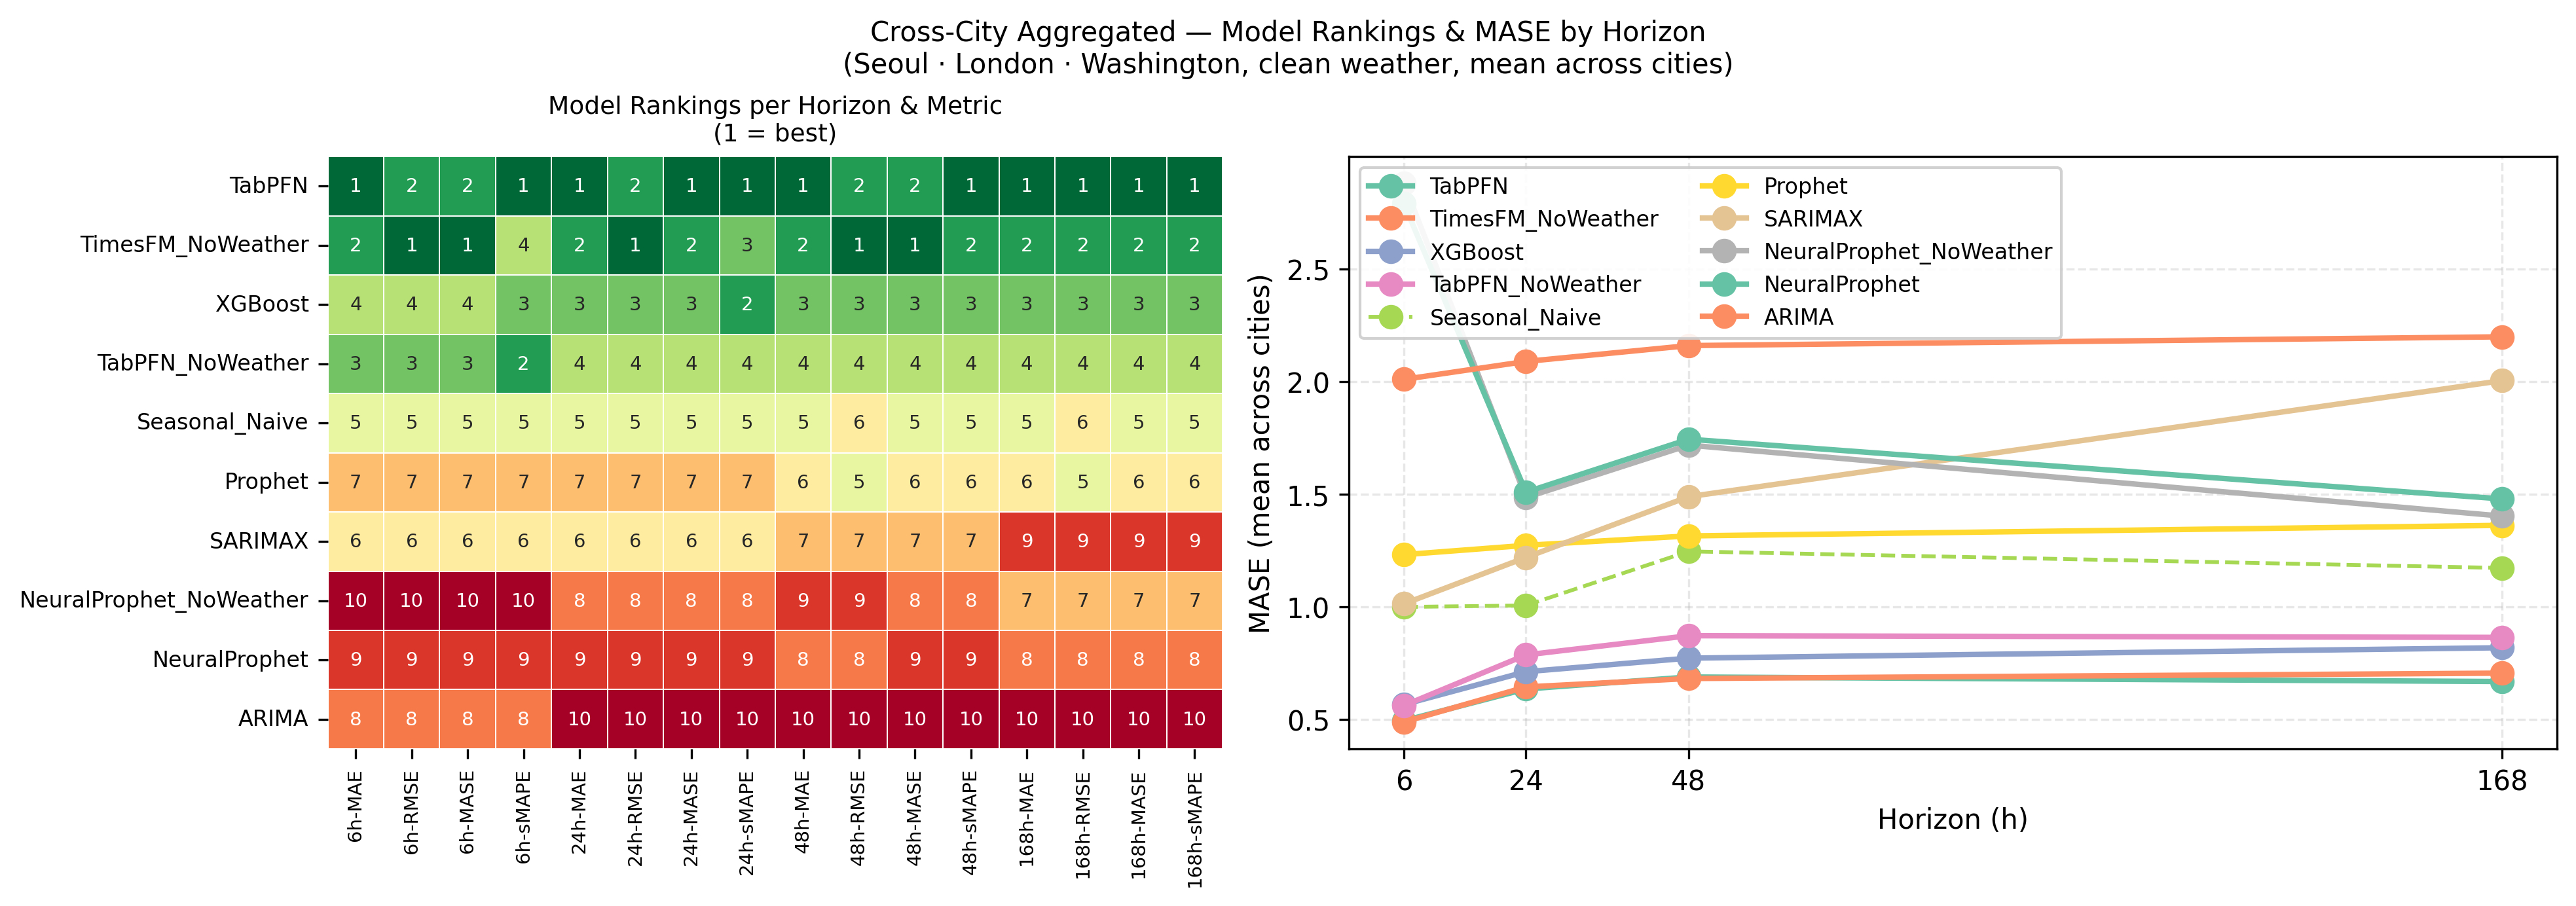

Saved → ../results/figures/cross_city/fig12_cross_city_heatmap_MASE_by_horizon.png


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 12 (Cross-City) — Ranking Heatmap + MASE Line Plot
# Aggregated across Seoul / London / Washington (clean_only, all horizons)
#
# Drop this cell into Section 3 of the notebook, after df_clean_all is built.
#
# df_clean_all : already constructed earlier — one row per (dataset, model,
#                horizon) for weather_scenario == 'clean_only'.
# MODEL_ORDER_RANKED : cross-city ranked model list (best → worst by MASE).
# ─────────────────────────────────────────────────────────────────────────────

metrics        = ['MAE', 'RMSE', 'MASE', 'sMAPE']
horizons       = sorted(df_clean_all['horizon'].astype(int).unique())
horizon_labels = [f'{h}h' for h in horizons]

# ── Step 1: average each metric across cities, per (model, horizon) ───────────
city_avg = (
    df_clean_all
    .groupby(['model', 'horizon'], as_index=True)
    .agg(
        MAE   = ('MAE_mean',   'mean'),
        RMSE  = ('RMSE_mean',  'mean'),
        MASE  = ('MASE_mean',  'mean'),
        sMAPE = ('sMAPE_mean', 'mean'),
    )
    .reset_index()
)

# Keep only models present in the cross-city ranking list
available_models = [m for m in MODEL_ORDER_RANKED if m in city_avg['model'].unique()]
city_avg = city_avg[city_avg['model'].isin(available_models)]

# ── Step 2: rank models within each (horizon, metric) slice ──────────────────
rank_rows = []
for h in horizons:
    df_h = city_avg[city_avg['horizon'] == h].copy()
    for m in metrics:
        df_h[f'{m}_rank'] = df_h[m].rank(method='min', ascending=True)
        rank_rows.append(
            df_h[['model', f'{m}_rank']]
            .assign(Horizon=f'{h}h', Metric=m)
            .rename(columns={f'{m}_rank': 'Rank'})
        )

df_ranks  = pd.concat(rank_rows, ignore_index=True)
df_pivot  = df_ranks.pivot_table(index='model', columns=['Horizon', 'Metric'],
                                  values='Rank')
df_pivot  = df_pivot.reindex(available_models)
desired_cols = pd.MultiIndex.from_product([horizon_labels, metrics],
                                           names=['Horizon', 'Metric'])
df_pivot  = df_pivot.reindex(columns=desired_cols)
df_pivot.index.name = None

# ── Step 3: draw figure ───────────────────────────────────────────────────────
fig, (ax_hm, ax_ln) = plt.subplots(
    1, 2, figsize=(13, 4.5), constrained_layout=True,
    gridspec_kw={'width_ratios': [1.0, 1.35]}
)

# — Left: ranking heatmap —
sns.heatmap(
    df_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
    ax=ax_hm, cbar=False, annot_kws={'fontsize': 7},
    linewidths=0.4, linecolor='white',
)
ax_hm.set_title('Model Rankings per Horizon & Metric\n(1 = best)', fontsize=9)
ax_hm.set_xlabel('')
ax_hm.tick_params(axis='x', labelrotation=90, labelsize=7)
ax_hm.tick_params(axis='y', labelsize=8)

# — Right: MASE line plot by horizon —
for i, model in enumerate(available_models):
    md = city_avg[city_avg['model'] == model].sort_values('horizon')
    ax_ln.plot(
        md['horizon'].astype(int), md['MASE'],
        marker='o', label=model, color=colors[i % len(colors)]
    )

# Mark Seasonal_Naive as dashed baseline reference
sn_line = [ln for ln in ax_ln.get_lines()
           if ax_ln.get_legend_handles_labels()[1][
               ax_ln.get_lines().index(ln)] == 'Seasonal_Naive']
if sn_line:
    sn_line[0].set_linestyle('--')
    sn_line[0].set_linewidth(1.4)

ax_ln.set_xlabel('Horizon (h)')
ax_ln.set_ylabel('MASE (mean across cities)')
ax_ln.set_xticks(horizons)
ax_ln.grid(True, alpha=0.3, linestyle='--')
ax_ln.legend(loc='upper left', framealpha=0.9, fontsize=8,
             ncol=1 if len(available_models) <= 9 else 2)

fig.suptitle(
    'Cross-City Aggregated — Model Rankings & MASE by Horizon\n'
    '(Seoul · London · Washington, clean weather, mean across cities)',
    fontsize=10
)

out_path = '../results/figures/cross_city/fig12_cross_city_heatmap_MASE_by_horizon.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved → {out_path}')


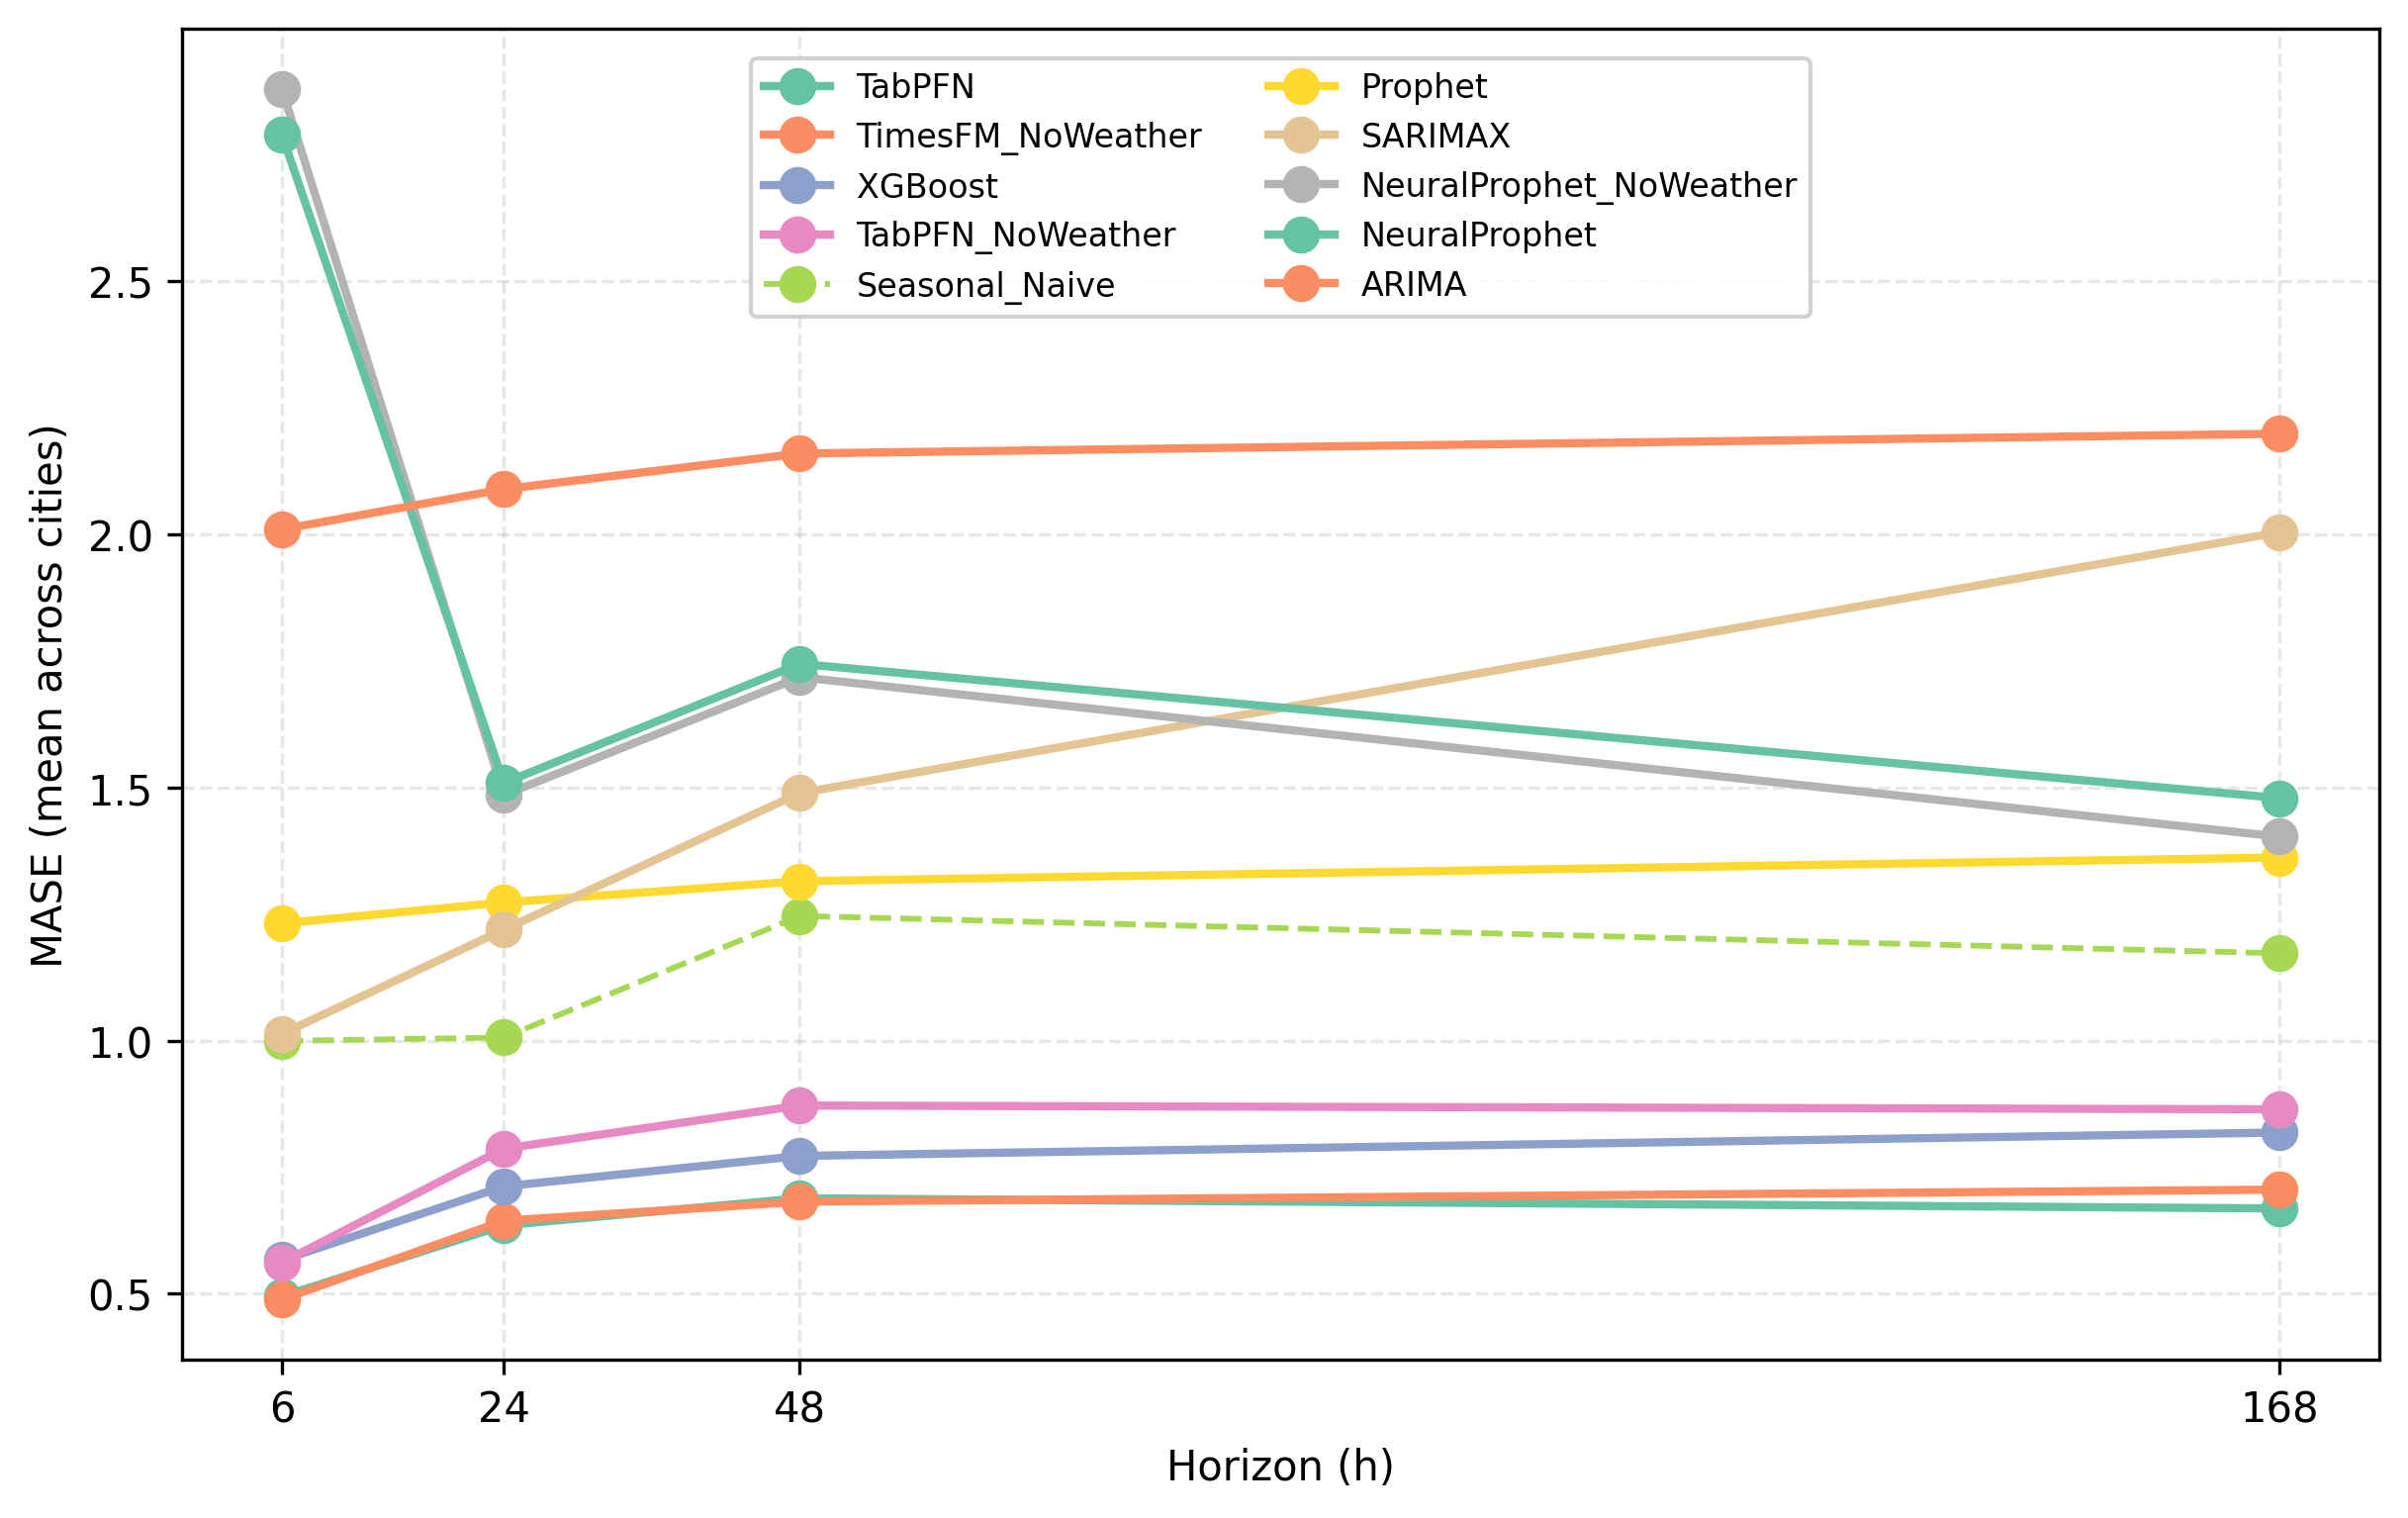

Saved → figC5_mase_by_horizon.png


In [19]:
# Figure CX — Cross-City MASE by Horizon (single panel)

city_avg_mase = (
    df_all_clean
    .groupby(['model', 'horizon'], as_index=False)['MASE_mean']
    .mean()
)

available_m = [m for m in MODEL_ORDER_RANKED if m in city_avg_mase['model'].unique()]
horizons_m  = sorted(city_avg_mase['horizon'].astype(int).unique())

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for model in available_m:
    idx = MODEL_ORDER_RANKED.index(model)
    md  = city_avg_mase[city_avg_mase['model'] == model].sort_values('horizon')
    ax.plot(
        md['horizon'].astype(int), md['MASE_mean'],
        marker='o', label=model,
        color=colors[idx % len(colors)],
        linestyle='--' if model == 'Seasonal_Naive' else '-',
        linewidth=1.4  if model == 'Seasonal_Naive' else 2.0,
    )

ax.set_xlabel('Horizon (h)')
ax.set_ylabel('MASE (mean across cities)')
ax.set_xticks(horizons_m)
ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_title(
    # 'Cross-City: MASE by Forecast Horizon', fontsize=10
# )
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=2,
          framealpha=0.9, fontsize=8)

fig.savefig('../results/figures/cross_city/figC5_mase_by_horizon.png',
            dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved → figC5_mase_by_horizon.png')

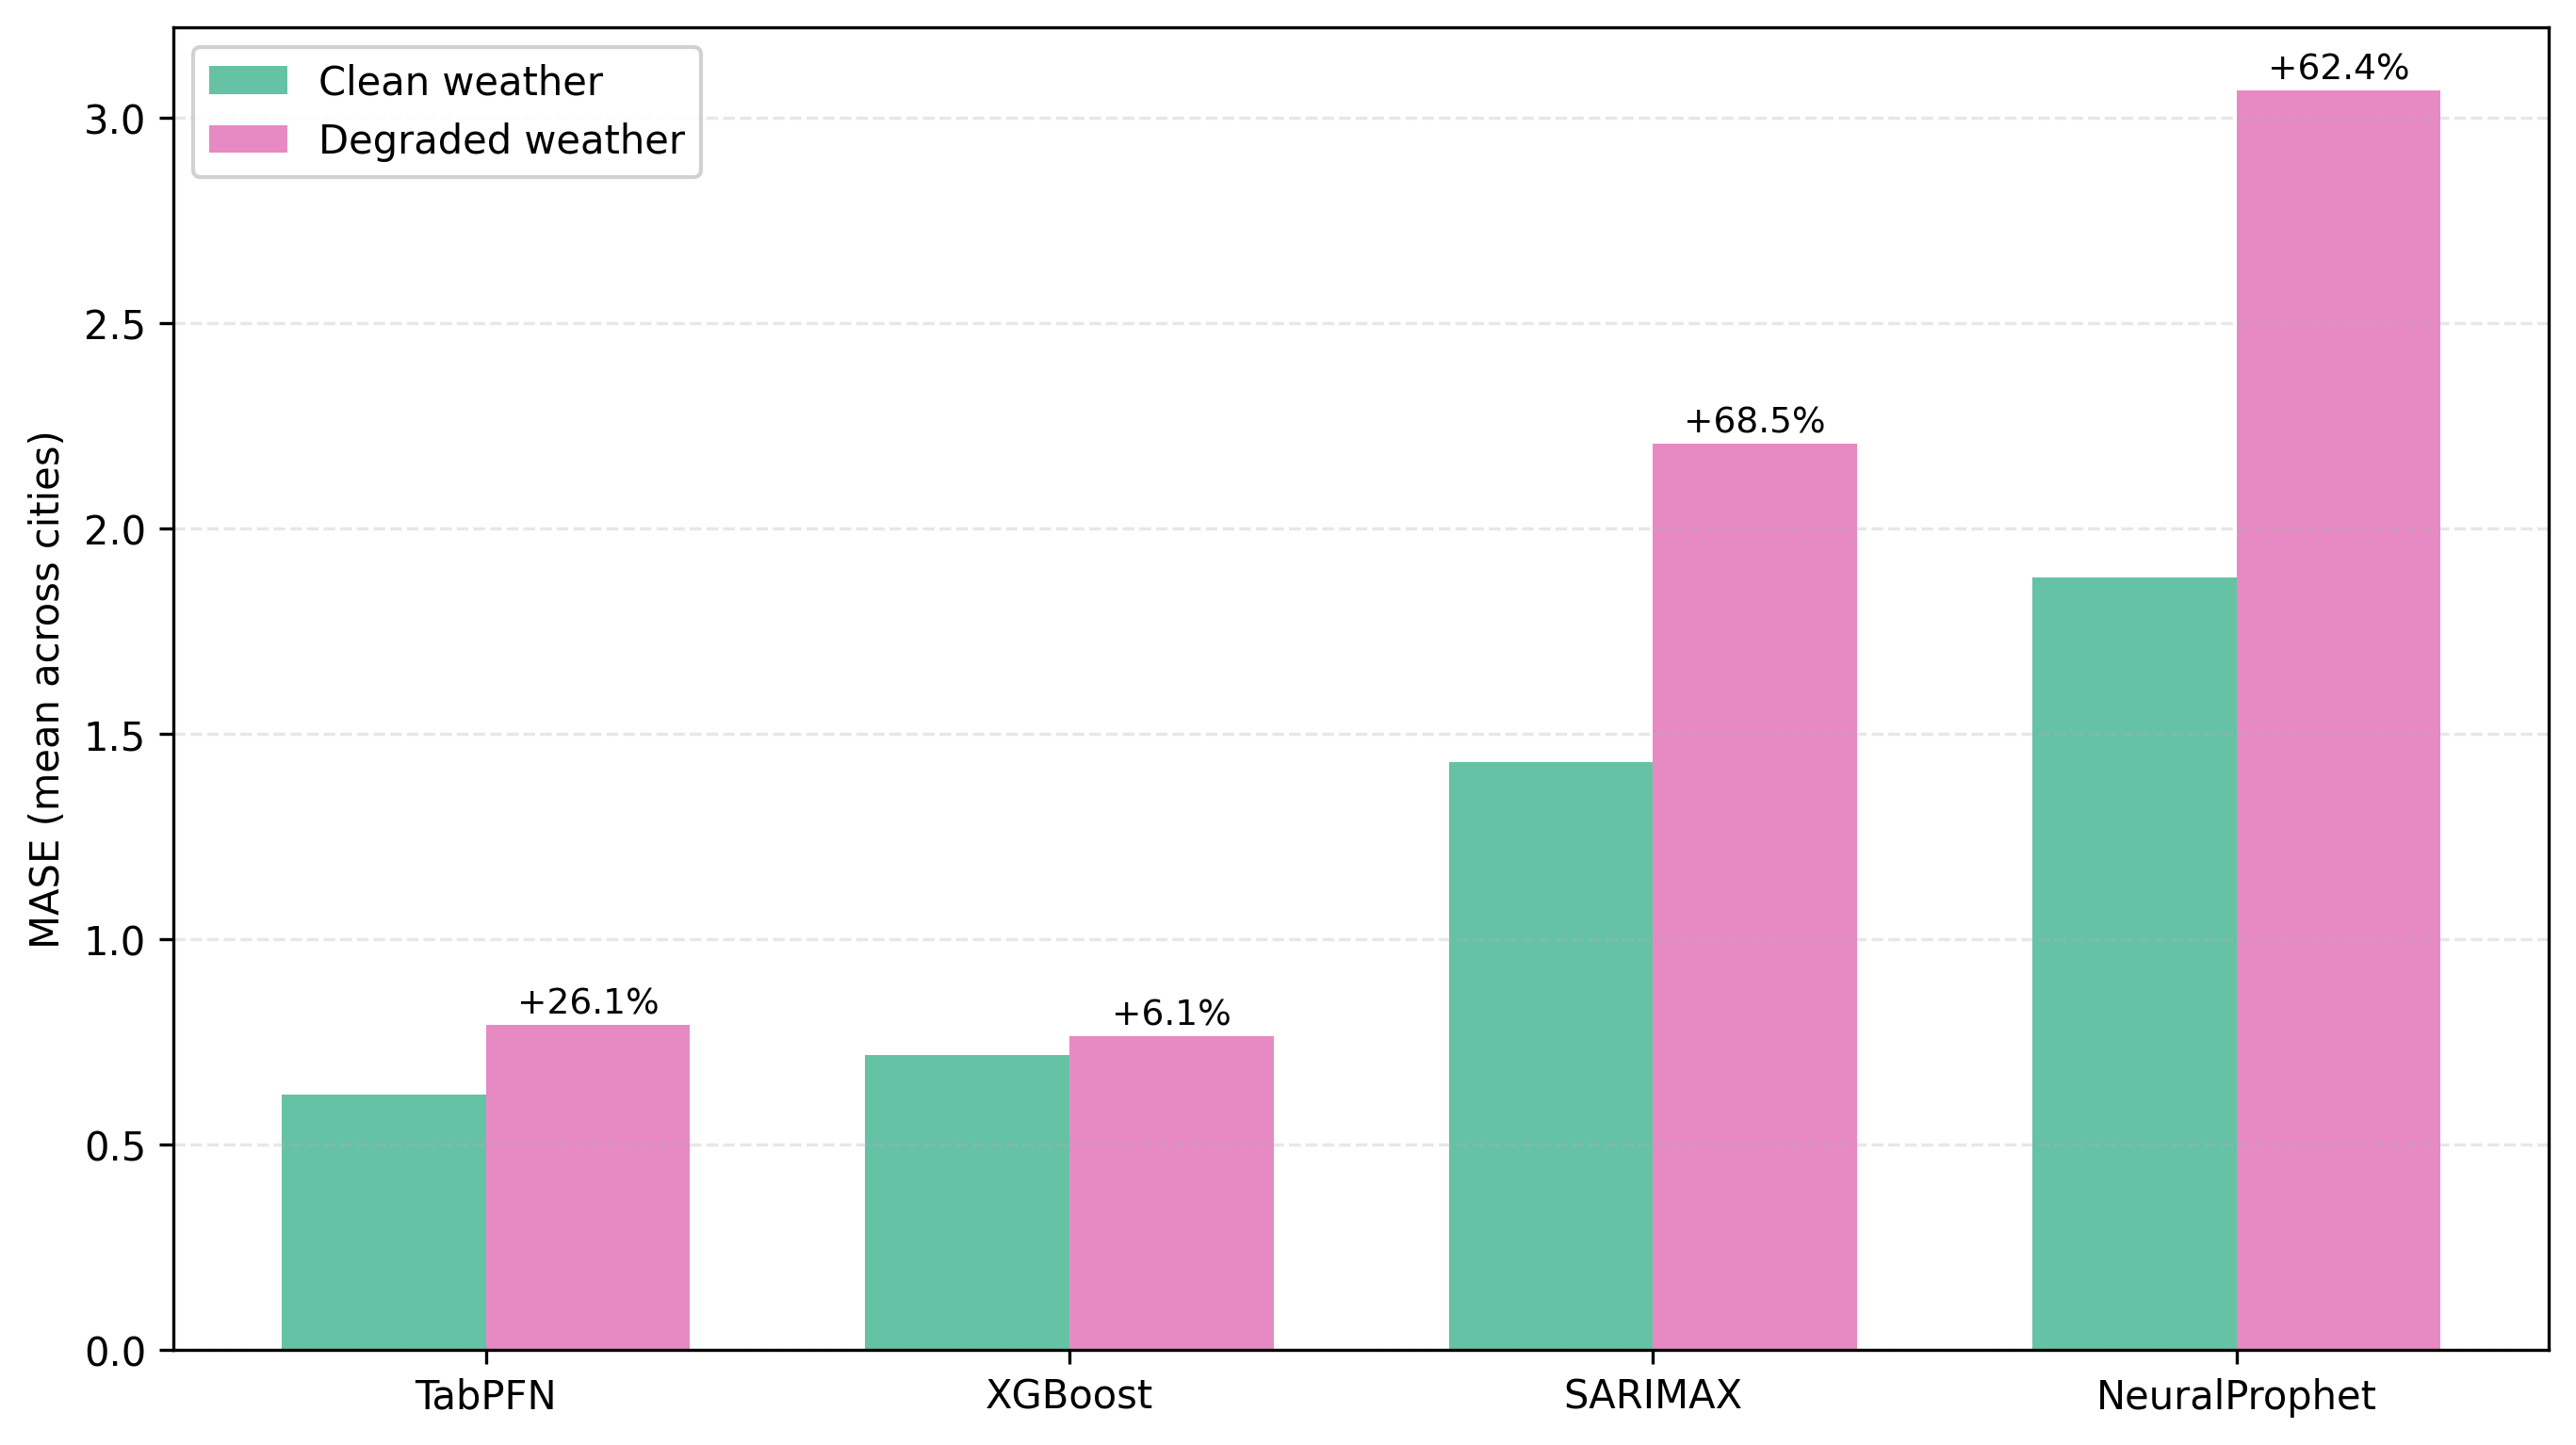

Saved → figC6_degradation_mase_bars.png


In [20]:
# Figure CX — Cross-City grouped bars: Clean vs Degraded MASE (fig 6 style)

deg_cross_mase = []
for ds in DATASETS:
    c_ds = df_all_clean[df_all_clean['dataset'] == ds]
    d_ds = df_all_degraded[df_all_degraded['dataset'] == ds]
    if d_ds.empty:
        continue
    for model in WEATHER_MODELS:
        if model not in c_ds['model'].unique() or model not in d_ds['model'].unique():
            continue
        c_val = c_ds[c_ds['model'] == model]['MASE_mean'].mean()
        d_val = d_ds[d_ds['model'] == model]['MASE_mean'].mean()
        deg_cross_mase.append({'dataset': ds, 'model': model,
                               'Clean': c_val, 'Degraded': d_val,
                               'pct': (d_val - c_val) / c_val * 100})

df_deg = pd.DataFrame(deg_cross_mase)
models_plot = [m for m in MODEL_ORDER_RANKED if m in df_deg['model'].unique()]

# Average across cities
avg = df_deg.groupby('model')[['Clean', 'Degraded', 'pct']].mean().loc[models_plot]

x     = np.arange(len(models_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
bars1 = ax.bar(x - width/2, avg['Clean'],    width, label='Clean weather',    color=colors[0])
bars2 = ax.bar(x + width/2, avg['Degraded'], width, label='Degraded weather', color=colors[3])

for b, pct in zip(bars2, avg['pct']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'+{pct:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('MASE (mean across cities)')
ax.set_xticks(x)
ax.set_xticklabels(models_plot)
ax.legend(framealpha=0.9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.savefig('../results/figures/cross_city/figC6_degradation_mase_bars.png',
            dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved → figC6_degradation_mase_bars.png')

In [71]:
rows = []
for model in WEATHER_MODELS:
    c = df_all_clean[df_all_clean['model'] == model]['MASE_mean'].mean()
    d = df_all_degraded[df_all_degraded['model'] == model]['MASE_mean'].mean()
    rows.append({'Model': model, 'Clean_MASE': round(c,2), 'Degraded_MASE': round(d,2),
                 'Increase': round(d-c,2), 'Increase_%': round((d-c)/c*100,2)})

deg_mase_df = pd.DataFrame(rows).sort_values('Increase_%')
print(deg_mase_df.to_string(index=False))
deg_mase_df.to_csv('../results/tables/cross_city/tableC4_degradation_mase.csv', index=False)

        Model  Clean_MASE  Degraded_MASE  Increase  Increase_%
      XGBoost        0.72           0.76      0.05        6.31
       TabPFN        0.62           0.79      0.17       27.23
      SARIMAX        1.43           2.21      0.77       54.14
NeuralProphet        1.88           3.07      1.19       63.09


# Section 4: fev-bench style metrics
## Win rates, Skill scores, and Bootstrap confidence intervals

In [21]:
# ── FEV-BENCH STYLE METRICS ─────────────────────────────────────────────────────
# Win rates, skill scores, and bootstrap confidence intervals

def geometric_mean(arr):
    """Compute geometric mean, handling zeros and negative values."""
    arr = np.asarray(arr)
    # Replace zeros with tiny value, skip negatives
    arr_safe = np.where(arr > 0, arr, 1e-10)
    return np.exp(np.mean(np.log(arr_safe)))

def clip_ratio(x, lower=0.01, upper=100):
    """Clip ratio to [lower, upper] to reduce outlier influence."""
    return np.clip(x, lower, upper)

def compute_skill_score(errors_model, errors_baseline, lower=0.01, upper=100):
    """
    Skill score: 1 - geometric_mean(errors_model / errors_baseline)
    
    Values > 0: model beats baseline
    Values = 0: model equals baseline
    Values < 0: model worse than baseline
    """
    ratios = errors_model / errors_baseline
    clipped = clip_ratio(ratios, lower, upper)
    geom = geometric_mean(clipped)
    return (1.0 - geom) * 100  # % improvement

def compute_pairwise_win_rate(errors_j, errors_k):
    """
    Win rate of model j vs k: fraction of tasks where j beats k
    Returns % (0-100)
    """
    wins = (errors_j < errors_k).sum()
    ties = (errors_j == errors_k).sum()
    n = len(errors_j)
    return 100.0 * (wins + 0.5 * ties) / n

def bootstrap_pairwise_metrics(errors_model_j, errors_model_k, errors_baseline, 
                                B=1000, ci=95):
    """
    Bootstrap pairwise win rate and skill score with confidence intervals.
    
    Resamples tasks (rows) with replacement B times.
    """
    np.random.seed(42)
    n_tasks = len(errors_model_j)
    
    win_rates_boot = []
    skill_scores_boot = []
    
    for _ in range(B):
        idx = np.random.choice(n_tasks, size=n_tasks, replace=True)
        ej = errors_model_j.iloc[idx].values if hasattr(errors_model_j, 'iloc') else errors_model_j[idx]
        ek = errors_model_k.iloc[idx].values if hasattr(errors_model_k, 'iloc') else errors_model_k[idx]
        eb = errors_baseline.iloc[idx].values if hasattr(errors_baseline, 'iloc') else errors_baseline[idx]
        
        wr = compute_pairwise_win_rate(ej, ek)
        ss = compute_skill_score(ej, eb)
        
        win_rates_boot.append(wr)
        skill_scores_boot.append(ss)
    
    alpha = (100 - ci) / 2
    lower_wr = np.percentile(win_rates_boot, alpha)
    upper_wr = np.percentile(win_rates_boot, 100 - alpha)
    
    lower_ss = np.percentile(skill_scores_boot, alpha)
    upper_ss = np.percentile(skill_scores_boot, 100 - alpha)
    
    return {
        'win_rate_mean': np.mean(win_rates_boot),
        'win_rate_ci': (lower_wr, upper_wr),
        'skill_score_mean': np.mean(skill_scores_boot),
        'skill_score_ci': (lower_ss, upper_ss),
    }

print("✓ fev-bench metrics functions loaded")

✓ fev-bench metrics functions loaded


In [22]:
# ── Prepare aggregated metrics across all tasks (cities × horizons) ─────────────
# Clean scenario only

# Aggregate to (model, dataset, horizon) level
agg_clean = (
    df_agg[df_agg['weather_scenario'] == 'clean_only']
    .copy()
)

# Pivot to model × task matrix
# Task = (dataset, horizon) combination
agg_clean['task'] = agg_clean['dataset'] + '_h' + agg_clean['horizon'].astype(str)
error_matrix = agg_clean.pivot_table(
    index='task', 
    columns='model', 
    values='MASE_mean',
    aggfunc='mean'
)

print(f"Error matrix shape: {error_matrix.shape}")
print(f"Tasks (dataset × horizon): {error_matrix.shape[0]}")
print(f"Models: {error_matrix.shape[1]}")
print(f"\nTasks: {error_matrix.index.tolist()[:5]}...")
print(f"\nMissing values per model:")
print(error_matrix.isnull().sum())

Error matrix shape: (12, 10)
Tasks (dataset × horizon): 12
Models: 10

Tasks: ['london_h168', 'london_h24', 'london_h48', 'london_h6', 'seoul_h168']...

Missing values per model:
model
ARIMA                      0
NeuralProphet              0
NeuralProphet_NoWeather    0
Prophet                    0
SARIMAX                    0
Seasonal_Naive             0
TabPFN                     0
TabPFN_NoWeather           0
TimesFM_NoWeather          0
XGBoost                    0
dtype: int64


In [23]:
# ── Pairwise Win Rates (all models, all tasks) ────────────────────────────────
# Wjk = fraction of tasks where model j beats model k

models = error_matrix.columns.tolist()
n_models = len(models)

win_rate_matrix = pd.DataFrame(
    np.nan, 
    index=models, 
    columns=models
)

for j in models:
    for k in models:
        if j == k:
            win_rate_matrix.loc[j, k] = 50.0  # tie vs self
        else:
            ej = error_matrix[j].dropna()
            ek = error_matrix[k].dropna()
            # Take intersection of valid tasks
            valid = ej.index.intersection(ek.index)
            ej = ej.loc[valid]
            ek = ek.loc[valid]
            
            wr = compute_pairwise_win_rate(ej, ek)
            win_rate_matrix.loc[j, k] = wr

# Reorder by MODEL_ORDER_RANKED
win_rate_matrix = win_rate_matrix.reindex(MODEL_ORDER_RANKED)[MODEL_ORDER_RANKED]

print("Pairwise Win Rate Matrix (Wjk):")
print(win_rate_matrix.round(1))
win_rate_matrix.to_csv('../results/tables/cross_city/win_rate_matrix.csv')
print("\nSaved: win_rate_matrix.csv")

Pairwise Win Rate Matrix (Wjk):
                         TabPFN  TimesFM_NoWeather  XGBoost  TabPFN_NoWeather  \
TabPFN                     50.0               41.7    100.0             100.0   
TimesFM_NoWeather          58.3               50.0    100.0             100.0   
XGBoost                     0.0                0.0     50.0              75.0   
TabPFN_NoWeather            0.0                0.0     25.0              50.0   
Seasonal_Naive              0.0                0.0      0.0               0.0   
Prophet                     0.0                0.0      0.0               0.0   
SARIMAX                     0.0                0.0      0.0               0.0   
NeuralProphet_NoWeather     0.0                0.0      0.0               0.0   
NeuralProphet               0.0                0.0      0.0               0.0   
ARIMA                       0.0                0.0      0.0               0.0   

                         Seasonal_Naive  Prophet  SARIMAX  \
TabPFN         

In [24]:
# ── Skill Scores vs Baseline (Seasonal_Naive) ──────────────────────────────────
# Sj = 1 - geometric_mean(MASE_model / MASE_baseline) [in %]

baseline_model = 'Seasonal_Naive'
skill_scores = {}

for model in MODEL_ORDER_RANKED:
    em = error_matrix[model].dropna()
    eb = error_matrix[baseline_model].dropna()
    
    # Intersection
    valid = em.index.intersection(eb.index)
    em = em.loc[valid].values
    eb = eb.loc[valid].values
    
    ss = compute_skill_score(em, eb)
    skill_scores[model] = ss

skill_df = pd.DataFrame([skill_scores]).T
skill_df.columns = ['Skill Score (%)']
skill_df = skill_df.sort_values('Skill Score (%)', ascending=False)

print(f"Skill Scores vs {baseline_model}:")
print(skill_df.round(1))
skill_df.to_csv('../results/tables/cross_city/skill_scores.csv')
print("\nSaved: skill_scores.csv")

Skill Scores vs Seasonal_Naive:
                         Skill Score (%)
TimesFM_NoWeather                   44.3
TabPFN                              44.2
XGBoost                             36.2
TabPFN_NoWeather                    31.8
Seasonal_Naive                       0.0
Prophet                            -17.3
SARIMAX                            -23.7
NeuralProphet_NoWeather            -62.1
NeuralProphet                      -64.1
ARIMA                              -88.1

Saved: skill_scores.csv


In [25]:
# ── Bootstrap Confidence Intervals (top 4 models) ───────────────────────────────
# 95% CI on pairwise win rates and skill scores

top_models = MODEL_ORDER_RANKED[:4]
baseline = baseline_model

boot_results = {}

print("Computing bootstrap CIs (B=1000)...\n")

for j in top_models:
    for k in [m for m in top_models if m != j]:
        ej = error_matrix[j].dropna()
        ek = error_matrix[k].dropna()
        eb = error_matrix[baseline].dropna()
        
        valid = ej.index.intersection(ek.index).intersection(eb.index)
        ej = ej.loc[valid]
        ek = ek.loc[valid]
        eb = eb.loc[valid]
        
        result = bootstrap_pairwise_metrics(ej, ek, eb, B=1000)
        boot_results[(j, k)] = result
        
print(f"Bootstrap results for top {len(top_models)} models:")
print(f"\n{'Model J':<18} {'Model K':<18} {'Win Rate':<8} {'95% CI':<20}")
print("="*65)

for (j, k), res in boot_results.items():
    wr = res['win_rate_mean']
    ci = res['win_rate_ci']
    ci_str = f"({ci[0]:.1f}, {ci[1]:.1f})"
    print(f"{j:<18} {k:<18} {wr:>6.1f}% {ci_str:>20}")
    
print("\nSkill Score (% improvement over baseline):")
print(f"\n{'Model J':<18} {'Model K':<18} {'Skill Score':<8} {'95% CI':<20}")
print("="*65)

for (j, k), res in boot_results.items():
    ss = res['skill_score_mean']
    ci = res['skill_score_ci']
    ci_str = f"({ci[0]:.1f}, {ci[1]:.1f})"
    print(f"{j:<18} {k:<18} {ss:>8.1f}% {ci_str:>20}")

Computing bootstrap CIs (B=1000)...

Bootstrap results for top 4 models:

Model J            Model K            Win Rate 95% CI              
TabPFN             TimesFM_NoWeather    41.9%         (16.7, 66.7)
TabPFN             XGBoost             100.0%       (100.0, 100.0)
TabPFN             TabPFN_NoWeather    100.0%       (100.0, 100.0)
TimesFM_NoWeather  TabPFN               58.1%         (33.3, 83.3)
TimesFM_NoWeather  XGBoost             100.0%       (100.0, 100.0)
TimesFM_NoWeather  TabPFN_NoWeather    100.0%       (100.0, 100.0)
XGBoost            TabPFN                0.0%           (0.0, 0.0)
XGBoost            TimesFM_NoWeather     0.0%           (0.0, 0.0)
XGBoost            TabPFN_NoWeather     75.5%        (50.0, 100.0)
TabPFN_NoWeather   TabPFN                0.0%           (0.0, 0.0)
TabPFN_NoWeather   TimesFM_NoWeather     0.0%           (0.0, 0.0)
TabPFN_NoWeather   XGBoost              24.5%          (0.0, 50.0)

Skill Score (% improvement over baseline):

Model J  

In [26]:
# ── Win Rates by Horizon ────────────────────────────────────────────────────────
# Aggregated separately for each forecast horizon

horizons = sorted(agg_clean['horizon'].unique())
wr_by_h = {}

for h in horizons:
    df_h = agg_clean[agg_clean['horizon'] == h]
    em_h = df_h.pivot_table(
        index='dataset',
        columns='model',
        values='MASE_mean',
        aggfunc='mean'
    )
    
    wr_h = {}
    for model in MODEL_ORDER_RANKED:
        if model in em_h.columns:
            errors = em_h[model].dropna().values
            baseline_errors = em_h[baseline_model].dropna().values
            # Compare: win rate vs baseline
            wr = compute_pairwise_win_rate(errors, baseline_errors)
            wr_h[model] = wr
    
    wr_by_h[h] = wr_h

wr_by_h_df = pd.DataFrame(wr_by_h).T
wr_by_h_df = wr_by_h_df[MODEL_ORDER_RANKED]

print(f"Win Rates vs {baseline_model} by Horizon:")
print(wr_by_h_df.round(1))
wr_by_h_df.to_csv('../results/tables/cross_city/win_rates_by_horizon.csv')
print("\nSaved: win_rates_by_horizon.csv")

Win Rates vs Seasonal_Naive by Horizon:
     TabPFN  TimesFM_NoWeather  XGBoost  TabPFN_NoWeather  Seasonal_Naive  \
6     100.0              100.0    100.0             100.0            50.0   
24    100.0              100.0    100.0             100.0            50.0   
48    100.0              100.0    100.0             100.0            50.0   
168   100.0              100.0    100.0             100.0            50.0   

     Prophet  SARIMAX  NeuralProphet_NoWeather  NeuralProphet  ARIMA  
6        0.0     66.7                      0.0            0.0    0.0  
24       0.0      0.0                      0.0            0.0    0.0  
48      33.3     33.3                      0.0            0.0    0.0  
168      0.0      0.0                      0.0            0.0    0.0  

Saved: win_rates_by_horizon.csv


## Covariate Impact Analysis

In [27]:
# ── Covariate impact: clean vs degraded scenarios ───────────────────────────────
# FIXED: check if baseline exists before accessing



results_by_scenario = {}

for scenario in ['clean_only', 'degraded']:
    df_s = df_agg[df_agg['weather_scenario'] == scenario].copy()
    
    if len(df_s) == 0:
        print(f"⚠ No data for scenario: {scenario}")
        continue
    
    df_s['task'] = df_s['dataset'] + '_h' + df_s['horizon'].astype(str)
    em_s = df_s.pivot_table(
        index='task',
        columns='model',
        values='MASE_mean'
    )
    
    # Skip if baseline not in this scenario
    if baseline_model not in em_s.columns:
        print(f"⚠ {baseline_model} not in {scenario}, skipping")
        continue
    
    skill_s = {}
    for model in MODEL_ORDER_RANKED:
        if model in em_s.columns:
            em = em_s[model].dropna().values
            eb = em_s[baseline_model].dropna().values
            
            valid = min(len(em), len(eb))
            if valid > 0:
                ss = compute_skill_score(em[:valid], eb[:valid])
                skill_s[model] = ss
    
    results_by_scenario[scenario] = skill_s

if len(results_by_scenario) == 2:
    scenario_df = pd.DataFrame(results_by_scenario)
    scenario_df['degradation_impact'] = scenario_df.get('degraded', 0) - scenario_df.get('clean_only', 0)
    scenario_df = scenario_df.reindex(MODEL_ORDER_RANKED)
    
    print("Skill Score by Scenario (% vs Seasonal Naive):\n")
    print(scenario_df.round(1))
    scenario_df.to_csv('../results/tables/cross_city/skill_score_by_scenario.csv')
else:
    print(f"⚠ Only {len(results_by_scenario)} scenario(s) available, skipping comparison")

⚠ Seasonal_Naive not in degraded, skipping
⚠ Only 1 scenario(s) available, skipping comparison


In [28]:
# ── Figure: Win Rate Matrix Heatmap ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    win_rate_matrix,
    annot=True, fmt='.0f', cmap='RdYlGn', center=50,
    cbar_kws={'label': 'Win Rate (%)'}, ax=ax
)
ax.set_title('Pairwise Win Rates (%) — All Tasks', fontsize=12, fontweight='bold')
# ax.set_xlabel('Model K')
# ax.set_ylabel('Model J')
plt.tight_layout()
fig.savefig('../results/figures/cross_city/win_rate_heatmap.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: win_rate_heatmap.png")

Saved: win_rate_heatmap.png


In [29]:
# ── Figure: Skill Scores Barplot ───────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))
skill_df_sorted = skill_df.sort_values('Skill Score (%)', ascending=True)
colors_skill = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(skill_df_sorted)))
ax.barh(range(len(skill_df_sorted)), skill_df_sorted['Skill Score (%)'], color=colors_skill)
ax.set_yticks(range(len(skill_df_sorted)))
ax.set_yticklabels(skill_df_sorted.index)
ax.set_xlabel('Skill Score (% improvement over Seasonal Naive)')
ax.set_title('Skill Scores (fev-bench style)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig('../results/figures/cross_city/skill_scores.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: skill_scores.png")

Saved: skill_scores.png


## Summary

**fev-bench metrics added:**
1. **Win Rate Matrix (Wjk)**: pairwise % of tasks where model j beats model k
2. **Skill Scores (Sj)**: % improvement over Seasonal Naive using geometric mean
3. **Bootstrap CIs**: 95% confidence intervals on top models (B=1000 resamples)
4. **By-horizon breakdown**: win rates and skill scores for each h ∈ {6, 24, 48, 168}
5. **Scenario impact**: covariate benefit (clean vs degraded)

**Outputs saved:**
- `win_rate_matrix.csv`
- `skill_scores.csv`
- `win_rates_by_horizon.csv`
- `skill_score_by_scenario.csv`
- `win_rate_heatmap.png`
- `skill_scores.png`

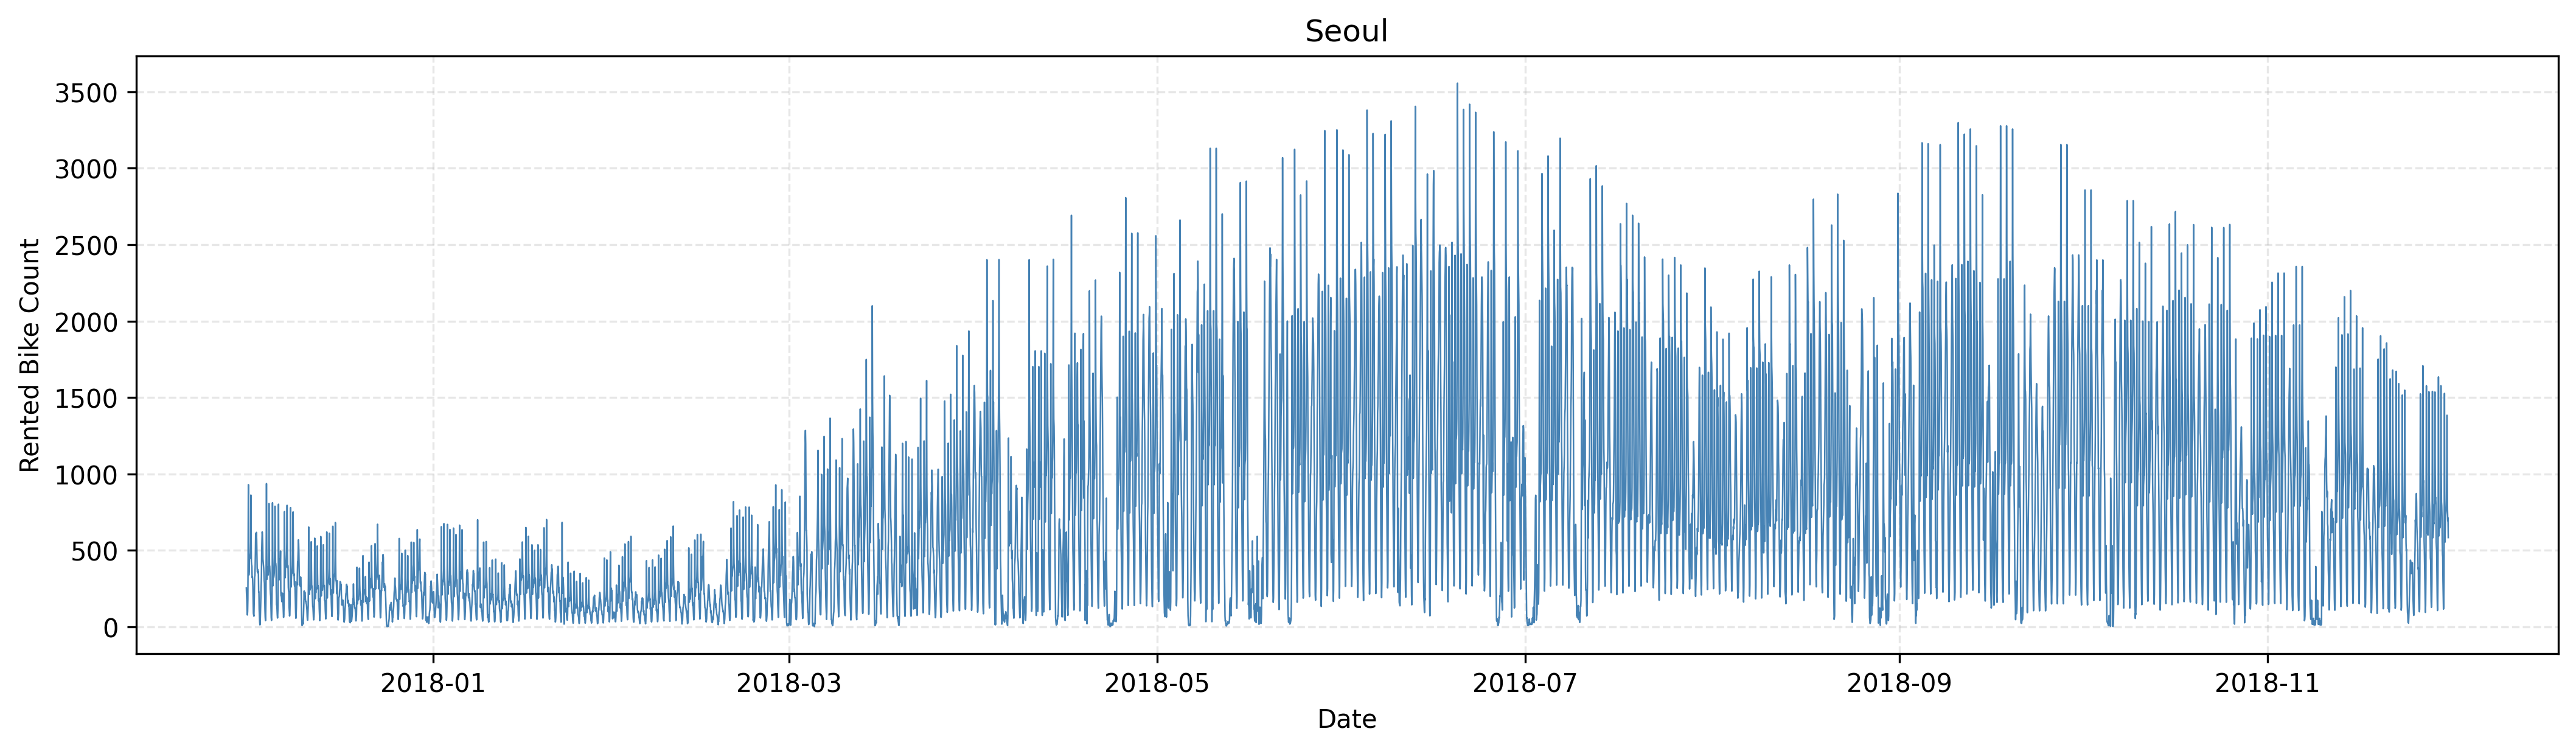

Saved → Seoul


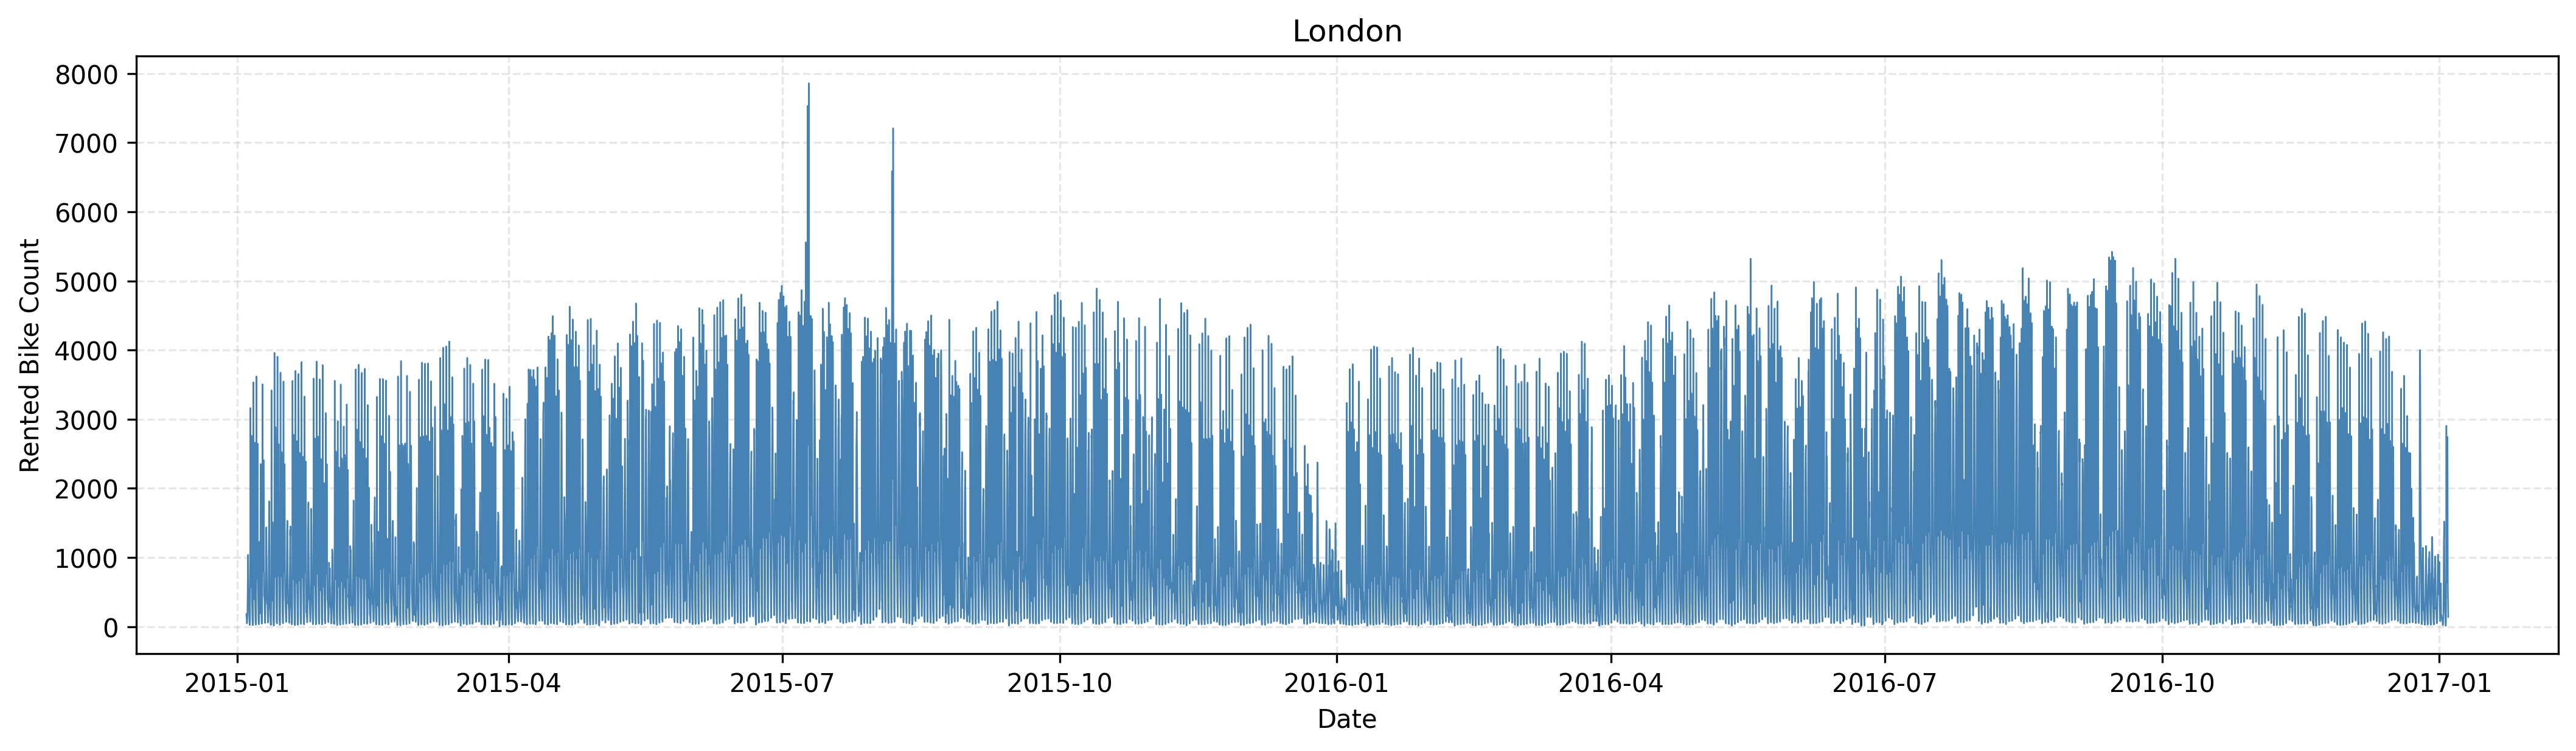

Saved → London


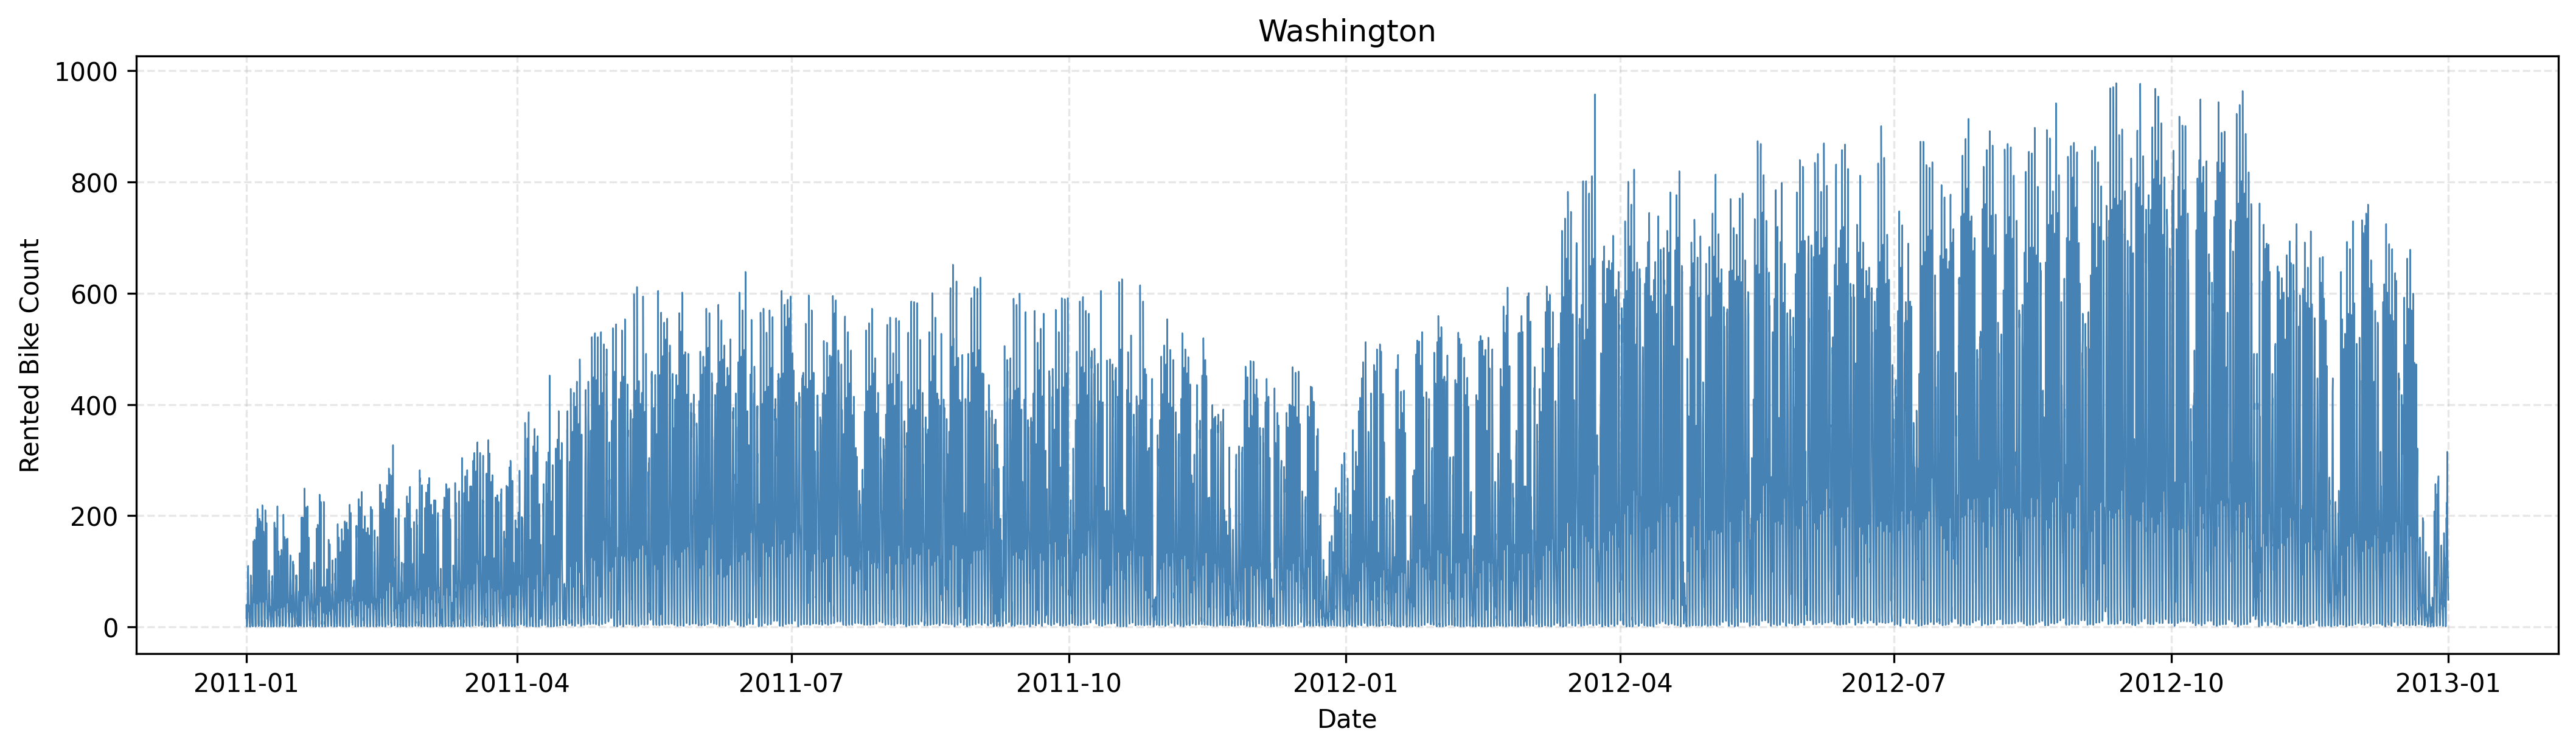

Saved → Washington


In [30]:
city_data = {
    'Seoul':      ('../data/SeoulBikeData.csv', 'Date',      'Rented Bike Count'),
    'London':     ('../data/LondonBikeData.csv', 'timestamp', 'cnt'),
    'Washington': ('../data/WashingtonBikeData.csv','timestamp', 'cnt'),
}

for city, (path, date_col, count_col) in city_data.items():
    df = pd.read_csv(path, parse_dates=[date_col])
    fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)
    ax.plot(df[date_col], df[count_col], linewidth=0.6, color='steelblue')
    ax.set_title(f'{city}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Rented Bike Count')
    ax.grid(alpha=0.3, linestyle='--')
    fig.savefig(f'../results/figures/{city.lower()}_rentals_over_time.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved → {city}')